# 30-Day Hospital Readmission Risk Prediction CatBoost Model
Hospital readmissions occur when a patient is re-hospitalized within a short period after discharge, typically within 30 days, and are a widely used measure of care quality. Readmissions are costly and often signal issues such as poor care coordination, inadequate discharge planning, or medication errors. Each year, nearly 3 million seniors are readmitted within 30 days, costing Medicare over 3 billion dollars. Approximately 78% of these readmissions are preventable, largely driven by medication non-adherence and insufficient post-discharge coordination. Early identification of high-risk patients enables timely interventions that improve patient outcomes and reduce costs. Advances in healthcare analytics, along with the introduction of the Centers for Medicare & Medicaid Services’ Hospital Readmissions Reduction Program, have accelerated the use of predictive analytics to address readmission risk. This project explores the use of machine learning to predict 30-day hospital readmissions risk. Specifically, we trained a CatBoost model to predict readmission risk for Caryfy’s caregiver agency clients and compared its performance to a baseline Logistic Regression model to quantify the uplift achieved through feature engineering and the use of a more advanced algorithm. Using ROC‑AUC as the primary evaluation metric, our goal is to build a CatBoost model that achieves an ROC‑AUC of at least 0.75. Both models were built using nine electronic health record datasets covering patient demographics, hospitalizations, medications, diagnoses, and allergies.This notebook details the data preparation, model development, and model evaluation results. For the rest of this notebook, Caryfy's caregiver agencies clients and patients will be used interchangeably.


**Python Packages and Module Information**

Please install relevant python packages before running the cells below. Please note that models in this notebook were trained using the following packages versions, it is strongly recommended to use these versions to prevent compatibility issues while running the cells below:

    numpy 1.26.4
    pandas 3.0.1
    shap 0.44.1
    catboost 1.2.10, 
    sklearn 1.8.0
    python 3.12.7
    matplotlib 3.9.2


## 1.0 Loading Datasets

In [4]:

#import needed packages and all datasets: code assumes dataset is in the same directory as this jupyter notebook
import pandas as pd
import os
import random
import numpy as np
SEED = 15
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

#Load client's fall information datasets
fallhis_df = pd.read_excel("Recent_fall_history.xls")
recentfall_df = pd.read_excel("Client_recent_fall.xls")

#Load client's medication information dataset
med_df = pd.read_excel("Client_medication.xls")

#Load client's hospitalization,diagnosis and allergies datasets
lasthos_df = pd.read_excel("Client_last_hospitalization_date.xls")
cgalert_df = pd.read_excel("Client_caregiver_alert.xls")
cancelapp_df = pd.read_excel("Client_cancel_appointment_due_to_hospital.xls")
allergies_df = pd.read_excel("Client_allergies.xls")
diag_df = pd.read_excel("client_diagnosis.xls")
details_df = pd.read_excel("client_details_with_dischargedate.xls")



## 2.0 Data Cleaning and Wrangling
Electronic health record (EHR) data is often noisy and requires substantial cleaning before it can be used for machine learning. Because client information was distributed across nine datasets, extensive data wrangling was performed to create a single consolidated dataset for model development. This section describes the steps taken to build that dataset. Additional, feature engineering and model specific data wrangling are discussed in the feature engineering and model training sections of this notebook.

### 2.0.1 Consolidated hospitalization dataset creation
Preliminary exploratory data analysis identified four datasets containing information related to client hospitalizations. One dataset directly documented hospitalization events, while the other three contained information from which hospitalizations could be inferred. Both actual and inferred events were consolidated into a single hospitalization dataset, which was then used to create the target feature, **30 days readmission flag**. 

The four datasets used were:

1. Client last hospitalization dataset
2. Client recent fall dataset
3. Client careiver alert dataset
4. Client cancel appointment due to hospitalization dataset

The subsequent code blocks outline the steps taken to combine these data sources and construct the model’s target feature.    

**Dataset 1 data wrangling** 

A high-level review of the recent fall dataset revealed a limited number of hospitalization records and hospitalization dates stored in an incorrect data type. These issues were resolved through appropriate data cleaning techniques.

In [8]:
# High level summary of the contents of the recent fall dataset
recentfall_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5687 entries, 0 to 5686
Data columns (total 7 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   UUID                                   5687 non-null   str           
 1   DoesClientHaveHistoryOfFalls           5590 non-null   str           
 2   HasClientFallenRecently                5636 non-null   str           
 3   FallRisk                               5549 non-null   str           
 4   HasClientHadAnyRecentHospitalizations  5580 non-null   str           
 5   HospitalizationDate                    885 non-null    str           
 6   CreatedOn                              5687 non-null   datetime64[us]
dtypes: datetime64[us](1), str(6)
memory usage: 575.0 KB


In [9]:
#rename recent fall dataset records create date to fall_assess_date
recentfall_df.rename(columns = {"CreatedOn" : "Fall_assess_date"},inplace = True)

      

In [10]:
#change recent fall hospitalization date to datetime to address wrong datatype issue
recentfall_df["HospitalizationDate"] = pd.to_datetime(recentfall_df["HospitalizationDate"])
#Extract patients with hospitalization records and add a column indicating the source of these records
fallhos_df = recentfall_df.loc[recentfall_df["HospitalizationDate"].notna()].reset_index(drop = True)
fallhos_df["Source"] = "recent_fall"


In [11]:
#extract the subset of the columns needed from the recent fall dataset after the updates 
fallhos_dfsub = fallhos_df.loc[:,["UUID","HospitalizationDate","Source"]]


#Normalize hospitalization dates to midnight in preparation for merging with other datasets and remove duplicates after normalizing
fallhos_dfsub["HospitalizationDate"] = pd.to_datetime(fallhos_dfsub["HospitalizationDate"]).dt.normalize()
fallhos_dfsub = fallhos_dfsub.drop_duplicates(subset = ["UUID","HospitalizationDate"])


                    

**Dataset 2 data wrangling**

A high-level review of the caregiver alert dataset identified additional hospitalization records. Because hospitalization dates were not explicitly captured, the record creation date was used as a proxy for the hospitalization date.

In [13]:
print(cgalert_df.info())


<class 'pandas.DataFrame'>
RangeIndex: 2914 entries, 0 to 2913
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   UUID                         2914 non-null   str           
 1   ClientFellTakenToHospital    1183 non-null   str           
 2   ClientFellNoInjury           1239 non-null   str           
 3   ClientIsHospitalized         1224 non-null   str           
 4   ClientConditionHasChanged    1235 non-null   str           
 5   ClientRequireScheduleChange  1194 non-null   str           
 6   WokenUpToProvaideCare        2663 non-null   str           
 7   CreatedOn                    2914 non-null   datetime64[us]
dtypes: datetime64[us](1), str(7)
memory usage: 312.4 KB
None


In [14]:
#Select patients with hospitalization events from the caregiver alert dataset
cgalert_hos = cgalert_df.loc[(cgalert_df["ClientIsHospitalized"] == "yes") |(cgalert_df["ClientFellTakenToHospital"] == "yes")].reset_index(drop=True)

#Select the subset of columns needed from the extracted dataset and clean up in preparation for merging with other datasets
cgalert_sub = cgalert_hos.loc[:,["UUID","CreatedOn"]]
cgalert_sub.rename(columns = {"CreatedOn": "HospitalizationDate"}, inplace = True)
cgalert_sub["Source"] = "caregiver_alert"



In [15]:

#Normalize dates to midnight and remove duplicates after normalizing
cgalert_sub["HospitalizationDate"] = pd.to_datetime(cgalert_sub["HospitalizationDate"]).dt.normalize()
cgalert_sub = cgalert_sub.drop_duplicates(subset = ["UUID","HospitalizationDate"]).reset_index(drop = True)
cgalert_sub["Source"] = "caregiver_alert"
cgalert_sub.info()


<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   UUID                 1218 non-null   str           
 1   HospitalizationDate  1218 non-null   datetime64[us]
 2   Source               1218 non-null   str           
dtypes: datetime64[us](1), str(2)
memory usage: 89.6 KB


**Dataset 3 data wrangling** 

A review of the **reason** field of the cancel appointment due to hospitalization dataset identified additional hospitalization records. In depth analysis of this reason field revealed that some cancellations were related to caregiver hospitalizations, requiring filtering to exclude non-client events. Because hospitalization dates were not explicitly provided, the appointment start date was used as a proxy for the hospitalization date.

In [17]:
print(cancelapp_df.loc[:2,"Reason"])
print(cancelapp_df.info())
#print(cancelapp_df.nunique())

0                                      In the Hospital
1    Client has been admitted to the hospital, no d...
2    Client has been admitted to the hospital, no d...
Name: Reason, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 27333 entries, 0 to 27332
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   UUID                  27333 non-null  str           
 1   StartAppointmentDate  27333 non-null  datetime64[us]
 2   Status                27333 non-null  str           
 3   Reason                27333 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 2.4 MB
None


In [18]:
#Data wrangling to extract only client related hospitalization events. Select events where cancellation reason is due to client's hospitalization and not caregiver's hospitalization

#Identify observations due to caregiver hospitalization
caregiver_hosplist = cancelapp_df.loc[cancelapp_df["Reason"].str.contains("CG|caregiver",case= False, na = False)]
cg_listcorrind = [3,4,11,12,21,*range(24,48),49,61,63,66,67,*range(76,81),*range(85,99),*range(100,104),105,106,*range(109,114),*range(115,122),124,125,*range(129,133),
*range(135,141),*range(144,152),*range(156,159),*range(160,163),164,165,168,*range(170,184),*range(185,191),192,196,197,202,205,206,*range(209,213),222,*range(224,230),
231,232,234,*range(241,248),249,250,252,*range(254,257),258,*range(262,278),*range(281,291),295,296,297,*range(299,311),*range(312,315),320,321,324,325,329,330,333,335,
336,338,339,*range(341,346),352,353,354,*range(357,366),368]
cg_listcorruniq = caregiver_hosplist["Reason"].unique().tolist()

cg_hospcorr = [cg_listcorruniq[i] for i in cg_listcorrind]

#Filter observations related to caregiver hospitalization
cancelapp_cleandf = cancelapp_df.loc[~cancelapp_df["Reason"].isin(cg_hospcorr)].reset_index(drop = True)
#cancelapp_cleandf.loc[cancelapp_cleandf["UUID"] == "d0f177cb-cc58-4b89-b0e4-a8e28805b569"]
cancelapp_clean2df = cancelapp_cleandf.drop([12284,12285,12286,12287,23390,23391]).reset_index(drop = True)
print(cancelapp_clean2df.info())
clean_check = cancelapp_clean2df.loc[cancelapp_clean2df["Reason"].str.contains("CG|caregiver",case= False, na = False)]


<class 'pandas.DataFrame'>
RangeIndex: 26710 entries, 0 to 26709
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   UUID                  26710 non-null  str           
 1   StartAppointmentDate  26710 non-null  datetime64[us]
 2   Status                26710 non-null  str           
 3   Reason                26710 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 2.4 MB
None


In [19]:
#Rename startappointment date as hospitalization date
cancelapp_clean2df.rename(columns = {"StartAppointmentDate" : "HospitalizationDate"}, inplace = True)

#Extract subset of cleaned dataset needed for merging with other datasets 
cancelapp_sub = cancelapp_clean2df.loc[:,["UUID","HospitalizationDate"]]

#Normalize dates to midnight and drop duplicates after normalizing
cancelapp_sub["HospitalizationDate"] = pd.to_datetime(cancelapp_sub["HospitalizationDate"]).dt.normalize()
cancelapp_sub = cancelapp_sub.drop_duplicates(subset=["UUID","HospitalizationDate"]).reset_index(drop=True)
cancelapp_sub["Source"] = "cancel_appointment"
cancelapp_sub.info()
                    

<class 'pandas.DataFrame'>
RangeIndex: 25844 entries, 0 to 25843
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   UUID                 25844 non-null  str           
 1   HospitalizationDate  25844 non-null  datetime64[us]
 2   Source               25844 non-null  str           
dtypes: datetime64[us](1), str(2)
memory usage: 1.9 MB


**Dataset 4 data wrangling**

The last hospitalization dataset was the primary source of hospitaization events and contained 1321 event records . The main data cleaning done to this dataset was to remove duplicate entries.

In [21]:

lasthos_sub = lasthos_df.sort_values(["UUID","HospitalizationDate"])

#Normalize dates to midnight and remove duplicates after normalizing
lasthos_sub["HospitalizationDate"] = pd.to_datetime(lasthos_sub["HospitalizationDate"]).dt.normalize()
lasthos_sub = lasthos_sub.drop_duplicates(subset = ["UUID","HospitalizationDate"]).reset_index(drop = True)
lasthos_sub["Source"] = "last_hosp"


**Consolidated hospitalization dataset creation**

In [23]:
#concatenate all hospitalization records and check for duplicates 
#select uuid , hospitalization,discharge dates and source from all hospitalization dataframes
fallhos_concat = fallhos_dfsub.loc[:,["UUID","HospitalizationDate","Source"]]
cancelhosp_sub = cancelapp_sub.loc[:,["UUID","HospitalizationDate","Source"]]
cgalert_concat = cgalert_sub.loc[:,["UUID","HospitalizationDate","Source"]]
lasthos_concat = lasthos_sub.loc[:,["UUID","HospitalizationDate","Source"]]
allhos_combdf = pd.concat([lasthos_concat,fallhos_concat,cancelhosp_sub,cgalert_concat],ignore_index = True)

allhos_combdf.info()
              

<class 'pandas.DataFrame'>
RangeIndex: 29248 entries, 0 to 29247
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   UUID                 29248 non-null  str           
 1   HospitalizationDate  29248 non-null  datetime64[us]
 2   Source               29248 non-null  str           
dtypes: datetime64[us](1), str(2)
memory usage: 2.2 MB


In [24]:
#Normalize hospitalization column
allhos_combdf["HospitalizationDate"] = pd.to_datetime(allhos_combdf["HospitalizationDate"]).dt.normalize()


In [25]:
#check for duplicates and remove duplicates in consolidated dataset

duplicate_rows = allhos_combdf[allhos_combdf.duplicated(subset= ["UUID","HospitalizationDate"])]
print(len(duplicate_rows))

#remove duplicate rows
allhos_combdfclean = allhos_combdf.drop_duplicates(subset= ["UUID","HospitalizationDate"]).reset_index(drop=True)
allhos_combdfclean.info()

429
<class 'pandas.DataFrame'>
RangeIndex: 28819 entries, 0 to 28818
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   UUID                 28819 non-null  str           
 1   HospitalizationDate  28819 non-null  datetime64[us]
 2   Source               28819 non-null  str           
dtypes: datetime64[us](1), str(2)
memory usage: 2.1 MB


### 2.0.2  Target Feature Creation

To create the target feature, **30-day readmission flag**, discharge dates were required for each hospitalization event. Although some discharge dates were available in the client details dataset, they were not directly linked to specific hospitalization events, and discharge dates were missing for events extracted from the four hospitalization-related datasets. To address this, an algorithm was developed to estimate pseudo discharge dates for each hospitalization in the consolidated dataset. A discharge was assumed to occur when the gap between consecutive hospitalization dates for the same hospital stay exceeded one day. These estimated discharge dates were then compared against available discharge dates and updated where appropriate. The finalized discharge dates, together with hospitalization dates, were used to compute the target feature for supervised modeling. The following code blocks outline this process.

**Discharge Dates Estimation**

In [28]:
#Estimate discharge dates for all hospitalization events
allhos_combdfclean = allhos_combdfclean.sort_values(["UUID","HospitalizationDate"])
allhos_combdfclean["prior_date"] = allhos_combdfclean.groupby("UUID")["HospitalizationDate"].shift()


allhos_combdfclean["new_hospitalization"] = ((allhos_combdfclean["HospitalizationDate"] - allhos_combdfclean["prior_date"]).dt.days.ne(1))
allhos_combdfclean["newhosp_id"] = allhos_combdfclean.groupby("UUID")["new_hospitalization"].cumsum()


#Extract start and end dates for each hospitalization event
allhos_combdffinal = (allhos_combdfclean.groupby(["UUID","newhosp_id"]).agg(HospitalizationDate = ("HospitalizationDate","min"),
                                                                     DischargeDate = ("HospitalizationDate","max"),
                                                                           Source = ("Source", lambda x:sorted(x.unique()))).reset_index())



allhos_combdffinal["hosp_duration"] = (allhos_combdffinal["DischargeDate"] - allhos_combdffinal["HospitalizationDate"]).dt.days
print(allhos_combdffinal.info()) 


<class 'pandas.DataFrame'>
RangeIndex: 7268 entries, 0 to 7267
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   UUID                 7268 non-null   str           
 1   newhosp_id           7268 non-null   int64         
 2   HospitalizationDate  7268 non-null   datetime64[us]
 3   DischargeDate        7268 non-null   datetime64[us]
 4   Source               7268 non-null   object        
 5   hosp_duration        7268 non-null   int64         
dtypes: datetime64[us](2), int64(2), object(1), str(1)
memory usage: 597.2+ KB
None


In [29]:
#Compare discharge dates estimates with provided discharge dates in client details file

#extract discharge dates for details file
details_discdf = details_df[["UUID","DischargeDate"]]
details_discdf.rename(columns = {"DischargeDate":"DischargeDate_Provid"}, inplace = True)

#Merge with allhoscombfinal dataframe
allhos_combdffinal = pd.merge(allhos_combdffinal,details_discdf, on = "UUID", how = "left")


To determine when it is appropriate to overwrite the estimated discharge dates with the provided discharge dates, the following rules were used:
1. If the client's hospitalization duration(length of stay) is zero, their estimated discharge dates are only updated if there exists a provided discharge date that is within 30 days of their admission date.
2. For hospitalization duration greater than zero, their estimated discharge dates are updated when the difference between the estimated discharge date and provided discharge date is $\leq$ 10 days.

After these updates rules were applied, manual fixes were subsequently applied to observations where this logic failed. 

In [31]:
import numpy as np
# Applying discharge date update rules to the hospitalization events sourced from the recent fall dataset
allhos_combdffinal["DischargeDate_diff"] = (allhos_combdffinal["DischargeDate_Provid"] - allhos_combdffinal["DischargeDate"]).dt.days

allhos_combdffinal["DischargeDate_final"] = allhos_combdffinal["DischargeDate"]
allhos_combdffinal["DischargeDate_final"] = (np.where(((allhos_combdffinal["DischargeDate_diff"].notna()) 
                                                      &(allhos_combdffinal["Source"].str[0] == "recent_fall")
                                                      &(allhos_combdffinal["DischargeDate_diff"] >=0)
                                                      &(allhos_combdffinal["DischargeDate_diff"] <=30)),allhos_combdffinal["DischargeDate_Provid"],allhos_combdffinal["DischargeDate"]))



In [32]:
# Applying discharge date update rules to the hospitalization events sourced from the last_hospitalization dataset
allhos_combdffinal["DischargeDate_final"] = (np.where(((allhos_combdffinal["DischargeDate_diff"].notna()) 
                                                      &(allhos_combdffinal["Source"].str[0] == "last_hosp")
                                                      &(allhos_combdffinal["DischargeDate_diff"] >=0)
                                                      &(allhos_combdffinal["DischargeDate_diff"] <=30)),allhos_combdffinal["DischargeDate_Provid"],allhos_combdffinal["DischargeDate_final"]))



Manually fixed where update logic failed e.g having the same discharge date assigned to a unique client's multiple hospitalization events 


In [34]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "936012a5-30b4-4377-bfb1-4154bc2e6aec") &
                                                     (allhos_combdffinal["newhosp_id"]== 3),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [35]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "27b821e1-09fe-49c3-a586-51fa0aec0e0d") &
                                                     (allhos_combdffinal["newhosp_id"]== 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [36]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "454d645a-fc7b-474f-a62a-daac19cbfc1d") &
                                                     (allhos_combdffinal["newhosp_id"]== 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [37]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "45ef9655-b6dc-4d46-bf78-1be106e2d790") &
                                                     (allhos_combdffinal["newhosp_id"]== 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [38]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "7581ccf7-d36b-44de-9d5f-89ccf2cb2fc3") &
                                                     (allhos_combdffinal["newhosp_id"]== 2),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [39]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "867d3110-751c-4823-9c2c-42ea4814bc40") &
                                                     (allhos_combdffinal["newhosp_id"]== 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [40]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "8e40a943-8a11-4966-8bea-6fe06a909f36") &
                                                     (allhos_combdffinal["newhosp_id"]== 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [41]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "d87f8205-8d84-48d4-9f22-af5fcb598e2e") &
                                                     (allhos_combdffinal["newhosp_id"]== 5),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [42]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "33a64644-50d5-4294-b9f5-64eb6e0a9a9d") &(allhos_combdffinal["newhosp_id"]> 9)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [43]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "48bd6f51-a84e-490a-9c90-c702e0646cc5") &(allhos_combdffinal["newhosp_id"]> 1)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [44]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "74c6cf8a-e6cd-4cc4-87d7-aa9966ea347c") &(allhos_combdffinal["newhosp_id"]== 2)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [45]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "867d3110-751c-4823-9c2c-42ea4814bc40") &(allhos_combdffinal["newhosp_id"]== 3)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [46]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "95ffdd2c-0898-4851-9377-388735cc491c") &(allhos_combdffinal["newhosp_id"]== 14)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [47]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "95ffdd2c-0898-4851-9377-388735cc491c") &(allhos_combdffinal["newhosp_id"]== 15)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [48]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "aaa4799e-35eb-46e3-a7ff-6419c2bd24ca") &(allhos_combdffinal["newhosp_id"]== 2)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [49]:
#Applying discharge date update rules to the hospitalization events sourced from the caregiver alert dataset
allhos_combdffinal["DischargeDate_final"] = (np.where(((allhos_combdffinal["DischargeDate_diff"].notna()) 
                                                      &(allhos_combdffinal["Source"].str[0] == "caregiver_alert")
                                                      &(allhos_combdffinal["DischargeDate_diff"] >=0)
                                                      &(allhos_combdffinal["DischargeDate_diff"] <=30)),allhos_combdffinal["DischargeDate_Provid"],allhos_combdffinal["DischargeDate_final"]))


In [50]:
#Applying discharge date update rules to the hospitalization events sourced from the cancel appointment dataset
condition_1 = ((allhos_combdffinal["DischargeDate_diff"].notna()) 
                                                      &(allhos_combdffinal["Source"].str[0] == "cancel_appointment")
                                                      &(allhos_combdffinal["DischargeDate_diff"] >=0))
condition_2 = (((allhos_combdffinal["hosp_duration"] > 0) &(allhos_combdffinal["DischargeDate_diff"] <= 10))|
               ((allhos_combdffinal["hosp_duration"] == 0)&(allhos_combdffinal["DischargeDate_diff"] <=30)))

allhos_combdffinal["DischargeDate_final"] = np.where(condition_1 & condition_2,allhos_combdffinal["DischargeDate_Provid"],allhos_combdffinal["DischargeDate_final"])



Manually fix where update logic failed e.g having the same discharge date assigned to a unique client's multiple hospitalization events 

In [52]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "1f999567-778f-49f7-8122-a0e1e31cd95d") &
                                                     (allhos_combdffinal["newhosp_id"]== 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [53]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "1f999567-778f-49f7-8122-a0e1e31cd95d") &
                                                     (allhos_combdffinal["newhosp_id"]== 3),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [54]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "27b39fca-6a66-4582-909e-0b9b007728c9") &
                                                     (allhos_combdffinal["newhosp_id"]== 4),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [55]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "31c39c98-2ffd-4246-89e3-f3f8fb96d3b6") &
                                                     (allhos_combdffinal["newhosp_id"]== 2),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [56]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "49f64843-a88b-455f-ad14-fc9d83151a27") &
                                                     (allhos_combdffinal["newhosp_id"]> 3),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [57]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "4d337dc0-553a-4a58-8a30-81c07a8fe51b") &
                                                     (allhos_combdffinal["newhosp_id"]>= 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [58]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "57003d07-56b6-4106-8702-e796da5c6003") &
                                                     (allhos_combdffinal["newhosp_id"]== 2),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [59]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "5a3be68c-9749-4746-bce2-eb65444d1bb9") &
                                                     (allhos_combdffinal["newhosp_id"]== 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [60]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "5f520d4b-b0f2-4524-a05f-62a124942774") &
                                                     (allhos_combdffinal["newhosp_id"]== 2),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [61]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "64dfc8d6-f620-4432-b907-6f4ec425793e") &
                                                     (allhos_combdffinal["newhosp_id"]== 2),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [62]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "73b11ae0-4846-4cc7-a07c-ae177408e767") &
                                                     (allhos_combdffinal["newhosp_id"]== 2),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [63]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "7ebbdac4-e6db-463f-b6ee-de03b45763a3") &
                                                     (allhos_combdffinal["newhosp_id"]> 7),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [64]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "86c1dff4-9310-42dd-aa39-6a07370aa2dd") &
                                                     (allhos_combdffinal["newhosp_id"]== 5),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [65]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "8a0a4409-1100-4048-9546-12fefedc41c2") &
                                                     (allhos_combdffinal["newhosp_id"]== 1),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [66]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "92ae047f-8b02-475f-b23f-3f7f9619338b") &
                                                     (allhos_combdffinal["newhosp_id"]> 6) & (allhos_combdffinal["newhosp_id"]< 13) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [67]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "93a516e5-499e-4422-8e68-5cc239e57761") &
                                                     (allhos_combdffinal["newhosp_id"]== 3) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [68]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "95ffdd2c-0898-4851-9377-388735cc491c") &
                                                     (allhos_combdffinal["newhosp_id"]== 8) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [69]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "95ffdd2c-0898-4851-9377-388735cc491c") &
                                                     (allhos_combdffinal["newhosp_id"]> 9) & (allhos_combdffinal["newhosp_id"]<12),allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [70]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "a2f0eded-9c15-43a9-b572-e2884a7d1376") &
                                                     (allhos_combdffinal["newhosp_id"]== 2) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [71]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "acfab16c-6dcd-495c-b449-ffc74ac8c20a") &
                                                     (allhos_combdffinal["newhosp_id"]== 4) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [72]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "afa3ad79-efc5-42ec-9fd3-b4d8cb24a33f") &
                                                     (allhos_combdffinal["newhosp_id"]== 2) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [73]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "bd49e2f1-2b8b-447c-9fdf-4929d9c260e5") &
                                                     (allhos_combdffinal["newhosp_id"]>=1) & (allhos_combdffinal["newhosp_id"]<3) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [74]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "bda9427c-cc94-4c5d-815c-696e58f9971b") &
                                                     (allhos_combdffinal["newhosp_id"]==4) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [75]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "c58232af-76b0-4257-a088-8c8ccb246a95") &
                                                     (allhos_combdffinal["newhosp_id"]>3) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [76]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "ccaa8fe4-93c8-4d55-8a94-95fdbce83062") &
                                                     (allhos_combdffinal["newhosp_id"]==3) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [77]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "cea9df5d-5e32-4be6-80f7-3cfbdde2096f") &
                                                     (allhos_combdffinal["newhosp_id"]==4) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [78]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "d0b34a81-d56e-4cc8-acf6-7a9d288489dd") &
                                                     (allhos_combdffinal["newhosp_id"]>=10)& (allhos_combdffinal["newhosp_id"]<22) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [79]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "d8cc64ad-0f23-44d7-85ca-9666d64b3a7e") &
                                                     (allhos_combdffinal["newhosp_id"]==22) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [80]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "ea89a100-b753-47e2-9e29-081b08c929f8") &
                                                     (allhos_combdffinal["newhosp_id"]==1) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [81]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "ec62afcf-3991-4b9d-a978-acbbd42db295") &
                                                     (allhos_combdffinal["newhosp_id"]==8) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [82]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "ec7e072e-e02a-4582-8a99-41322b3cf2d6") &
                                                     (allhos_combdffinal["newhosp_id"]==1) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [83]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "f1f761b5-6bb9-4277-b5ff-bab910a15445") &
                                                     (allhos_combdffinal["newhosp_id"]==2) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [84]:
allhos_combdffinal["DischargeDate_final"] = (np.where((allhos_combdffinal["UUID"]== "95ffdd2c-0898-4851-9377-388735cc491c") &
                                                     (allhos_combdffinal["newhosp_id"]== 8) ,allhos_combdffinal["DischargeDate"],allhos_combdffinal["DischargeDate_final"]))

In [85]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "1160c137-6873-40c2-a1fe-1d28bd08903f") &(allhos_combdffinal["newhosp_id"]> 4)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [86]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "1990c488-686e-410e-adf1-9e45a92a63d3") &(allhos_combdffinal["newhosp_id"]== 2)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [87]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "36c7f36d-7428-447c-a019-0a017c9539af") &(allhos_combdffinal["newhosp_id"]> 3)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [88]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "384da0b1-35ba-478d-bc6d-e62c0787b0cc") &(allhos_combdffinal["newhosp_id"]> 1)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [89]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "4481d035-1009-4a75-93eb-5628b16f9d07") &(allhos_combdffinal["newhosp_id"]> 1)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [90]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "5a3be68c-9749-4746-bce2-eb65444d1bb9") &(allhos_combdffinal["newhosp_id"]==3)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

In [91]:
drop_idx = allhos_combdffinal[(allhos_combdffinal["UUID"]== "e99e1fb3-ed56-4e15-aef0-26dcd8c7a769") &(allhos_combdffinal["newhosp_id"]>1)].index

allhos_combdffinal.drop(drop_idx,inplace = True)

**30-day Readmission Flag Creation**

In [93]:
#Select columns needed for the calculation
allhos_final = allhos_combdffinal.loc[:,["UUID","HospitalizationDate","DischargeDate_final","Source"]].reset_index(drop=True)

allhos_final.rename(columns = {"DischargeDate_final" : "DischargeDate"}, inplace = True)
allhos_final = allhos_final.sort_values(["UUID","HospitalizationDate"]).reset_index(drop=True)

#Calculate new features needed to calculate the target feature
allhos_final["next_admission"] = (allhos_final.groupby("UUID")["HospitalizationDate"].shift(-1))
allhos_final["days_to_readmission"] =(allhos_final["next_admission"] - allhos_final["DischargeDate"]).dt.days

#Calculate the 30days readmission flag(Target feature)
allhos_final["30days_readmission"] = (allhos_final["days_to_readmission"].between(1,30)).astype(int)


## 3.0  Feature Engineering

Raw EHR data is primarily designed for billing, legal documentation, and operational needs, making it poorly suited for predictive modeling. To translate this transactional data into meaningful longitudinal clinical signals, extensive feature engineering is required. Readmission risk is driven by non-linear relationships, feature interactions, and temporal patterns that cannot be captured directly from raw EHR data. Feature engineering therefore plays a critical role in encoding patient history and transforming raw data into signals that CatBoost can effectively learn from, enabling building of a model that generalizes across patients and time.

In this project, feature engineering was performed in stages, with each stage deriving new features from a specific dataset. For each hospitalization event, the discharge date was used as the reference point, and data leakage was addressed by constructing time-aware features that relied only on information available prior to each event's discharge date. 

### 3.0.1 Feature Engineering Stage 1

Stage 1 focused on creating **Utilization Features** from the consolidated hospitalization events dataset. Utilization features  capture the frequency and recency of healthcare use and are strong predictors of readmission risk, as they serve as proxies for patient instability and indirectly encode multiple hidden factors like disease severity and comorbidities. For example, a patient with multiple prior 180 days admissions is more likely to be readmitted than one with no recent hospitalizations. The code below illustrates how these features were derived.

In [95]:
#Feature Engineered Utilization Features:create time aware prior readmission features to capture the total number of unique client 
#readmissions prior to the current discharge date
import numpy as np
allhos_final = allhos_final.sort_values(["UUID","HospitalizationDate"])
allhos_final["prior_readmission"] = (allhos_final.groupby("UUID")["30days_readmission"]
                                     .apply(lambda x:x.cumsum().shift(1)).reset_index(level =0,drop=True).fillna(0))


In [96]:
#calculate time aware prior hospitalization count to capture the total number of unique client hospitalizations prior to the current
# discharge date
allhos_final["prior_admitcount"] = (allhos_final.groupby("UUID").cumcount())


In [97]:
#function to create features that counts the number of admissions in the last 30/90/180 days prior to the current discharge date

from bisect import bisect_left
allhos_final = allhos_final.sort_values(["UUID","DischargeDate"])
def prior_admiss(dates,days_window):
    res_ls = []
    for i, date in enumerate(dates):
        win_cutoff = date - pd.Timedelta(days = days_window)
        left = bisect_left(dates, win_cutoff)
        res_ls.append(i-left)
    return res_ls

for window in[30,90,180]:
    col_name = f"prior_{window}d_admission"
    allhos_final[col_name] = allhos_final.groupby("UUID")["DischargeDate"].transform(lambda x: prior_admiss(list(x),window))
    



In [98]:
#Create days since last discharge features
allhos_final = allhos_final.sort_values(["UUID","DischargeDate"])
allhos_final["discharge_date_prev"] = (allhos_final.groupby("UUID")["DischargeDate"].shift(1))
allhos_final["days_since_last_discharge"] = (allhos_final["HospitalizationDate"] - allhos_final["discharge_date_prev"]).dt.days
#allhos_final["days_since_last_discharge"] = allhos_final["days_since_last_discharge"].fillna(9999)
allhos_final["recent_discharge_30d"] = (allhos_final["days_since_last_discharge"] <= 30).astype(int)
allhos_final["recent_discharge_90d"] = (allhos_final["days_since_last_discharge"] <= 90).astype(int)

In [99]:
#create frequent admitter feature 
allhos_final["admitter_frequent"] = (allhos_final["prior_180d_admission"] >= 3).astype(int)

In [100]:
#create super utilizer feature
allhos_final["utilizer_super"] = (allhos_final["prior_180d_admission"] >= 5).astype(int)

### 3.0.2 Feature Engineering Stage 2 

Stage 2 focused on engineering clinical and medication risk features, specifically comorbidity indicators, medication features, polypharmacy and medication change features, from the client medication dataset. Clinical risk features provides insights into who the patient is medically and can be powerful predictors of readmission risk especially when combined with utilization features while medication risk features measures how many medications a patient is taking and are good proxies for medication adherence issues, care complexity, adverse drug interactions risk and discharge instability which are known triggers for readmissions. Prior to feature creation, the medication dataset was further cleaned to resolve mixed data types, duplicate records, and formatting issues. To prevent data leakage and artificially inflating model performance, time-aware medication and polypharmacy features were engineered using only information available prior to each discharge date. The code blocks below illustrate these data cleaning and feature engineering steps.

**Medication Dataset Data Wrangling**

In [103]:
#Address mixed datatype issue in the Frequency column of the medication dataset
med_df.loc[med_df["Frequency"]=="Daily","Frequency"] = "1"
med_df["Frequency"] = med_df["Frequency"].astype(float)


In [104]:
#Function to address messy variations of the same medication in the Given for column of the medication dataset
import re

def txt_clean(txt):
    txt = str(txt).lower()
    #replace separators with space
    txt = re.sub(r'[()/,_\\\-]',' ', txt)
    #remove non-alphanumeric except space
    txt = re.sub(r'[^a-z0-9\s]','',txt)
    #Normalize spaces
    txt = re.sub(r'\s+',' ',txt).strip()
    return txt

#apply function to clean relevant columns in the medication dataset and remove duplicates medication
med_df["TypeOfMedication_clean"] = med_df["TypeOfMedication"].apply(txt_clean)
med_df["GivenFor_clean"] = med_df["GivenFor"].apply(txt_clean)
med_df = med_df.drop_duplicates(subset=["CareClientUUID","TypeOfMedication_clean"])




**Clinical Risk Features Creation**

In [106]:
#Create high risk medication classes based on ISMP and Beers and add to medication dataset

# A_Antimicrobial class pattern
pattern_A = r"\bgentamicin\b|\bgentamycin\b|\bvancomycin\b|\btobramycin\b|\bneomycin\b|\bstreptomycin\b|\bplazomicin\b|\baminoglycoside\w*"

#I- Insulin class pattern
pattern_I = r"""
\b(
    insulin|                              
    glargine|lispro|aspart|detemir|        
    humalog|humulin|lantus|toujeo|
    admelog|novolog|bagasular|humalong|              
    novolin|levemir|basaglar|novapen|ozempic|jardiance|              
    u[-\s]?100|u[-\s]?200|u[-\s]?300|u[-\s]?500|  
    70\/30|75\/25|50\/50                   
)\b
"""

#med_df["is_insulin"] = (med_df["TypeOfMedication_clean"].str.contains(Insulin_pattern, flags = re.IGNORECASE| re.VERBOSE, regex = True))

#N- Narcotics/Sedatives class pattern

pattern_N = (
    r"\bfentanyl\b|\bmorphine\b|\boxycodone\b|\bhydrocodone\b|"
    r"\bopioid\w*|\bbenzodiazepine\w*|\blorazepam\b|"
    r"\bmidazolam\b|\bpropofol\b"
    r"\balprazolam\b|\bdiazepam\b"
)


# C- Chemotherapeutics class pattern
pattern_C = r"\bmethotrexate\b|\bletrozole\b|\bkisqali\b|\bondansetron\b|\btrametinib\b|\banastrozole\b|\bcepecitabine\b"

# H - Heparin/Anticoagulants class pattern
pattern_H = (
    r"\bwarfarin\b|\bcoumadin\b|"
    r"\benoxaparin\b|\blovenox\b|"
    r"\brivaroxaban\b|\bapixaban\b|"
    r"\beliquis\b|\bjantoven\b|"
    r"\bdabigatran\b|\bheparin\b|"
    r"\banti\s?coagul\w*|\banticoag\w*"
)

# A - Antipsychotic class pattern
pattern_P = r"\bquetiapine\b|\bhaloperidol\b|\brisperidone\b|\bolanzapine\b|\bolanzepine\b|\bantipsychotic\w*"

# S - Steroid class pattern
pattern_S = r"\bprednisone\b|\bdexamethasone\b|\bmethylprednisone\b|\bmethelprednisone\b|\bsteroid\w*"

In [107]:
#create high risk medication flags based on their class patterns and add to medication dataset
high_risk_classes = {
    "antimicrobial": pattern_A,
    "narcotic_sedative": pattern_N,
    "chemotherapy": pattern_C,
    "anticoagulant": pattern_H,
    "antipsychotic": pattern_P,
    "steroid": pattern_S }

for class_name,pattern in high_risk_classes.items():
    med_df[f"is_{class_name}"]= (
        med_df["TypeOfMedication_clean"].str.contains(pattern, regex = True, na = False).astype(int))

med_df["is_insulin"] = (med_df["TypeOfMedication_clean"].str.contains(pattern_I, flags = re.IGNORECASE| re.VERBOSE, regex = True)).astype(int)


/var/folders/51/32q7pybd6hn6pgm_7hg6w6780000gn/T/ipykernel_53678/4215486337.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  med_df["is_insulin"] = (med_df["TypeOfMedication_clean"].str.contains(pattern_I, flags = re.IGNORECASE| re.VERBOSE, regex = True)).astype(int)


In [108]:
#create composite high risk flag in medication dataset
cols_risk = [col for col in med_df.columns if col.startswith("is_")]
med_df["is_high_risk_med"] = med_df[cols_risk].max(axis=1)


In [109]:
#create Comorbidity indicators in the medication dataset
givenfor_pattern = {
    "has_afib": r"\bafib\b|\batrial fibrillation\b",
    "has_stroke": r"\bstroke\b",
    "has_diabetes": r"\bdm\b|\bdiabet\w*",
    "has_cancer": r"\bcancer\b|\bchemotherap\w*",
    "has_infection": r"\binfect\w*|\bsepsis\b"
}

for feature, pattern in givenfor_pattern.items():
    med_df[feature] = (
        med_df["GivenFor_clean"].str.contains(pattern, regex = True, na = False).astype(int))




**Polypharmacy and Medication Change Features Creation**

In [111]:
#Function to create polypharmacy and medication change features and merge all created features with the hospitalization dataset
def med_features_create(df1, df2):
    df1consol = df1.copy()
    df2copy = df2.copy()
    #Ensure dates are in the right format
    df2copy["CreatedOn"] = pd.to_datetime(df2copy["CreatedOn"])
    df1consol["DischargeDate"] =pd.to_datetime(df1consol["DischargeDate"])
    #Sort dataframes
    df1consol = df1consol.sort_values(["UUID","DischargeDate"])
    df2copy = df2copy.sort_values(["CareClientUUID","CreatedOn"])
    # merge the two dataframes, use subset of columns as needed
    hos_meddf = df1consol[["UUID","DischargeDate"]].merge(df2copy, left_on = "UUID", right_on = "CareClientUUID", how = "left").drop("CareClientUUID", axis = 1)
    #prevent leakage
    hos_meddf = hos_meddf[hos_meddf["CreatedOn"] <= hos_meddf["DischargeDate"]]
    #calculate time difference window
    hos_meddf["medstart_since_days"] = (hos_meddf["DischargeDate"] - hos_meddf["CreatedOn"]).dt.days
    #hos_meddf.head(10)
    num_meds = hos_meddf.groupby(["UUID","DischargeDate"])["MedicationId"].nunique().reset_index().rename(columns = {"MedicationId" : "num_meds"})
    current_meds = hos_meddf[hos_meddf["Status"] == "Current"]
    num_current_meds = current_meds.groupby(["UUID","DischargeDate"])["MedicationId"].nunique().reset_index().rename(columns = {"MedicationId" : "num_current_meds"})
    prn_meds = hos_meddf[hos_meddf["Status"] == "PRN"]
    num_prn_meds = prn_meds.groupby(["UUID","DischargeDate"])["MedicationId"].nunique().reset_index().rename(columns = {"MedicationId" : "num_prn_meds"})
    prn_curr_meds = hos_meddf[(hos_meddf["Status"] == "PRN") |(hos_meddf["Status"] == "Current") ]
    num_prn_curr_meds = prn_curr_meds.groupby(["UUID","DischargeDate"])["MedicationId"].nunique().reset_index().rename(columns = {"MedicationId" : "num_prn_curr_meds"})
    #hos_meddf["days_since_newstart"] = (hos_meddf["DischargeDate"] - hos_meddf["CreatedOn"]).dt.days
    new_meds = hos_meddf[hos_meddf["Status"] == "New"]
    num_new_meds = new_meds.groupby(["UUID","DischargeDate"])["MedicationId"].nunique().reset_index().rename(columns = {"MedicationId" : "num_new_meds"})
    inj_meds = hos_meddf[hos_meddf["AmountUnit"] == "Syringes"]
    inj_meds_count = inj_meds.groupby(["UUID","DischargeDate"])["TypeOfMedication_clean"].nunique().reset_index().rename(columns = {"TypeOfMedication_clean" : "inj_meds_count"})
    high_risk_new_30d = hos_meddf[(hos_meddf["medstart_since_days"] <= 30) & (hos_meddf["is_high_risk_med"] == 1)]
    num_high_risk_new_30d = high_risk_new_30d.groupby(["UUID","DischargeDate"])["MedicationId"].nunique().reset_index().rename(columns = {"MedicationId" : "num_high_risk_new_30d"})
    antibiotics_14d = hos_meddf[(hos_meddf["medstart_since_days"] <= 14) & (hos_meddf["is_antimicrobial"] == 1)]
    num_antibiotics_last_14d = antibiotics_14d.groupby(["UUID","DischargeDate"])["MedicationId"].nunique().reset_index().rename(columns = {"MedicationId" : "num_antibiotics_last_14d"})
    curr_narcotics = hos_meddf[hos_meddf["is_narcotic_sedative"] == 1]
    num_narcotics = curr_narcotics.groupby(["UUID","DischargeDate"])["MedicationId"].nunique().reset_index().rename(columns = {"MedicationId" : "num_narcotics"})
    
    cols_risk = ['is_antimicrobial',
                 'is_narcotic_sedative',
                 'is_chemotherapy',
                 'is_anticoagulant',
                 'is_antipsychotic',
                 'is_steroid',
                 'is_insulin',
                 'is_high_risk_med'
                 ]
    risk_feat = hos_meddf.groupby(["UUID","DischargeDate"])[cols_risk].sum().reset_index()

    cols_condition = ['has_afib',
                      'has_stroke',
                      'has_diabetes',
                      'has_cancer',
                      'has_infection']
    cond_feat = hos_meddf.groupby(["UUID","DischargeDate"])[cols_condition].max().reset_index()
    
    #merge all features back to allhos_final dataframe
    df1consol = df1consol.merge(num_meds, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(num_current_meds, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(num_prn_meds, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(num_prn_curr_meds, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(num_new_meds, on=["UUID","DischargeDate"], how = "left")
    #df1consol = df1consol.merge(high_risk_count, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(inj_meds_count, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(num_high_risk_new_30d, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(num_antibiotics_last_14d, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(num_narcotics, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(risk_feat, on=["UUID","DischargeDate"], how = "left")
    df1consol = df1consol.merge(cond_feat, on=["UUID","DischargeDate"], how = "left")
    fill_cols = ["num_meds","num_current_meds","num_prn_meds","num_prn_curr_meds","num_new_meds","inj_meds_count","num_high_risk_new_30d","num_antibiotics_last_14d","num_narcotics"]
    for col in fill_cols:
        if col in df1consol.columns:
            df1consol[col] = df1consol[col].fillna(0)
    #df1consol.fillna(0, inplace = True)
    df1consol["med_change_ratio"] = np.where(df1consol["num_current_meds"]==0,0,df1consol["num_new_meds"]/df1consol["num_prn_curr_meds"])
    df1consol["polypharmacy_flag"] = (df1consol["num_meds"] >= 5).astype(int)
    return df1consol 

In [112]:
#run function to add all medication dataset features to the hospitalization dataset
allhos_fconsol = med_features_create(allhos_final, med_df)



/var/folders/51/32q7pybd6hn6pgm_7hg6w6780000gn/T/ipykernel_53678/1519981424.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2copy["CreatedOn"] = pd.to_datetime(df2copy["CreatedOn"])


In [113]:
#rename columns in the combined dataset to more descriptive names
allhos_fconsol.rename(columns = {"is_high_risk_med" : "high_risk_med_count"},inplace = True)


### 3.0.3 Feature Engineering Stage 3

Stage 3 focused on engineering frailty features from the client fall datasets. Frailty is among the strongest predictors of readmission but is rarely measured directly. Fall-related features serve as effective proxies by capturing a patient’s physical vulnerability. Patients with higher fall risk are more likely to experience fall events or medication side effects after discharge, increasing readmission risk. Accordingly, time-aware frailty features were created using only information available up to the discharge date to prevent data leakage. The code blocks below demonstrate how these features were generated.  

In [115]:
#create fall risk features from the client fall history dataset and add to the merged hospitalization-medication dataset
hosp_subset = allhos_fconsol[["UUID","HospitalizationDate","DischargeDate","30days_readmission"]]
fall2 = fallhis_df[["UUID", "FallsSinceLastVisit","CreatedOn"]]

#Used Createdon date as proxy for Fall report date
fall2.rename(columns = {"CreatedOn" : "Fall_report_date"},inplace = True)
hosp_fall = pd.merge(hosp_subset,fall2, on = "UUID", how = "left")

#Create time aware feature to prevent data leakage
hosp_fall= hosp_fall[hosp_fall["Fall_report_date"] <= hosp_fall["DischargeDate"]]

#sort dataframe in preparation for features creation
hos_fallsort = hosp_fall.sort_values(["UUID","DischargeDate","Fall_report_date"])

# create last fall risk status before each hospitalization discharge dates feature
last_risk_status = hos_fallsort.groupby(["UUID","DischargeDate"]).tail(1)
fallrisk_curr = last_risk_status[["UUID","DischargeDate","FallsSinceLastVisit"]]
fallrisk_curr["current_fall_risk"] = ( fallrisk_curr["FallsSinceLastVisit"].str.lower() == "yes").astype(int)
fallrisk_curr.drop(columns = "FallsSinceLastVisit", inplace = True)



In [116]:
#create feature to report if client has ever fallen before each discharge dates
hosp_fall["positive_fall"] = (hosp_fall["FallsSinceLastVisit"].str.lower() == "yes").astype(int)
fall_ever = hosp_fall.groupby(["UUID","DischargeDate"])["positive_fall"].max().reset_index(name = "fallen_ever")


In [117]:
#create if client has had a fall before 90 days of the current discharge date flag
hosp_fall["days_since_fall"] = (hosp_fall["DischargeDate"] - hosp_fall["Fall_report_date"]).dt.days
fall_90day = hosp_fall[(hosp_fall["days_since_fall"] <=90) & (hosp_fall["positive_fall"] == 1)]
fall_last_90day = fall_90day.groupby(["UUID","DischargeDate"])["positive_fall"].max().reset_index(name = "fall_last_90day")


In [118]:
#create days since last fall before current discharge date
pos_fall = hosp_fall[hosp_fall["positive_fall"] == 1]
fall_last = pos_fall.groupby(["UUID","DischargeDate"])["Fall_report_date"].max().reset_index()
fall_last["days_since_last_fall"] = (fall_last["DischargeDate"] - fall_last["Fall_report_date"]).dt.days
fall_last.drop(columns = "Fall_report_date", inplace = True)



In [119]:
#merge frailty features back to hospitalization-medication dataframe
allhos_fconsol = pd.merge (allhos_fconsol,fallrisk_curr, on = ["UUID","DischargeDate"], how = "left")
allhos_fconsol = pd.merge (allhos_fconsol,fall_ever, on = ["UUID","DischargeDate"], how = "left")
allhos_fconsol = pd.merge (allhos_fconsol,fall_last_90day, on = ["UUID","DischargeDate"], how = "left")
allhos_fconsol = pd.merge (allhos_fconsol,fall_last, on = ["UUID","DischargeDate"], how = "left")


### 3.0.4 Feature Engineering Stage 4

Stage 4 focused on engineering allergy related features from the client allergies dataset. Allergies, especially drug allergies can limit patient treatment options,lead to suboptimal therapy, and increase the risk of complications, thereby elevating readmission risk. The code blocks below demonstrate the data wrangling steps and the creation of allergy features used in the predictive models.

**Allergies Dataset Data Wrangling**

In [122]:
#impute missing values in the allergies flag columns based on values in the allergies columns
allergies_df.loc[allergies_df["EnvironmentalAllergy"].notna(),"IsEnvironmentalAllergy"] = 1
allergies_df.loc[allergies_df["FoodAllergy"].notna(),"IsFoodAllergy"] = 1
allergies_df.loc[allergies_df["MedicalAllergy"].notna(),"IsMedicalAllergy"] = 1

allergies_df["Total_allergies"] = (allergies_df[["IsEnvironmentalAllergy","IsFoodAllergy","IsMedicalAllergy"]].sum(axis=1)).astype(int)


In [123]:
#Add allergies flags to the combined hospitalization-medicaion-fall dataset
allergy_dfsub = allergies_df[["UUID","IsEnvironmentalAllergy","IsFoodAllergy","IsMedicalAllergy","Total_allergies"]]

allhos_allergydf = pd.merge(allhos_fconsol,allergy_dfsub, on = "UUID", how = "left")


### 3.0.5 Feature Engineering Stage 5

Stage 5 focused on engineering more complex **Comorbidity features** like Charlson Comorbidity Index(CCI), number of diagnosis and high risk diseases flags from the client diagnosis dataset. Comorbidities defined as the presence of one or more additional conditions alongside a primary diagnosis is known to significantly increase readmission risk by complicating recovery, increasing frailty, and requiring complex management. Comorbidity features quantify how medically complex and fragile a patient is thereby providing valuable insights into which patients are at high risk of readmission . Features like CCI capture overall disease burden and correlates well with increased readmission rates, longer hospital stays, and higher mortality. Specific high risk conditions like congestive heart failure, diabetes and renal diseases are also strongly associated with higher 30-day readmission rates hence the motivation for the creation of these targeted conditions flags. The code blocks below illustrate the feature generation process, along with data wrangling steps to address missing values and anomalous diagnosis records. 

**Diagnosis Dataset Data Wrangling**

In [126]:
#Impute missing values with "UNKNOWN"
cols = ["ICD10","diagnosis","DxSource","DiagnosisPriority"]
diag_df[cols] = diag_df[cols].fillna("UNKNOWN")


In [127]:

#function to combine diagnosis per patient
def comb_order(group):
    new_df = pd.Series({"comb_icd10": "|".join(group["ICD10"].astype(str)),
                        "comb_diagnosis": "|".join(group["diagnosis"].astype(str)),
                        "comb_Dxsource": "|".join(group["DxSource"].astype(str)),
                        "comb_DiagnosisPriority": "|".join(group["DiagnosisPriority"].astype(str))})
    return new_df

diagcomb_df = (diag_df.groupby("UUID", as_index = False).apply(comb_order))
  


In [128]:
#Map used to impute missing icd-10 code based on diagnosis column text: Map diagnosis text to appropriate icd-10 codes obtained 
#from the Centers for Medicare & Medicaid Services 2026-midyear_final-icd-10-cm-mappings spreadsheet
ICD_Pattern_Map = {
    # --- CCI: Cardiovascular ---
    r'(?i)heart failure|chf|congestive': 'I50.9',  
    r'(?i)myocardial infarction|heart attack|mi\b': 'I25.2',
    r'(?i)peripheral vascular|pvd|claudication': 'I73.9',   
    r'(?i)cerebrovascular|cva|stroke|tia\b|transient ischemic': 'I63.9', 
    r'(?i)hemiplegia|paralysis|paraplegia|quadriplegia': 'G82.20', 
    r'(?i)atrial fib|a-fib|arrhythmia|irregular heart': 'I48.91', 
    r'(?i)htn|hypertension|high blood pressure|hypertenion': 'I15.9',      

    # --- CCI: Respiratory ---
    r'(?i)copd|emphysema|obstructive pulmonary': 'J44.9',   
    r'(?i)asthma': 'J45.909',                                
    r'(?i)pneumonia': 'J18.9',                               
    r'(?i)respiratory failure|hypoxia': 'J96.9',             

    # --- CCI: Metabolic / Renal ---
    r'(?i)diabetes|dm|iddm|niddm': 'E11.9',                 
    r'(?i)type 1|juvenile': 'E10.9',                         
    r'(?i)kidney disease|ckd|renal failure|esrd|nephropathy': 'N18.9', 
    r'(?i)obesity|overweight|bmi': 'E66.9',                  
    r'(?i)hypothyroidism': 'E03.9',                          
    r'(?i)gout': 'M10.9',                                    

    # --- CCI: Neurological / Mental ---
    r'(?i)dementia|alzheimer': 'F03.90',                     
    r'(?i)depression|mdd|bipolar|anxiety': 'F32.9',         
    r'(?i)schizo|psychosis': 'F20.9',                        
    r'(?i)parkinson': 'G20',                                 
    r'(?i)seizure|epilepsy': 'G40.909',                      

    # --- CCI: Malignancy ---
    r'(?i)metastatic|metastasis': 'C79.9',                   
    r'(?i)lung cancer|lung ca\b': 'C34.90',                  
    r'(?i)breast cancer|breast ca\b': 'C50.919',             
    r'(?i)colon cancer|rectal cancer|colon ca\b': 'C18.9',
    r'(?i)prostate cancer|prostate ca\b': 'C61',             
    r'(?i)leukemia': 'C95.90',                               
    r'(?i)lymphoma': 'C85.9',                                
    r'(?i)cancer|malignancy|tumor|neoplasm': 'C80.1',        

    # --- Liver / GI ---
    r'(?i)cirrhosis|liver failure|hepatic': 'K74.60',        
    r'(?i)hepatitis': 'B18.9',                               
    r'(?i)gerd|reflux|heartburn': 'K21.9',                   
    r'(?i)ulcer|peptic': 'K27.9',                            

    # --- Infectious / Acute ---
    r'(?i)covid|coronavirus': 'U07.1',                       
    r'(?i)hiv|aids': 'B20',                                  
    r'(?i)sepsis|septic': 'A41.9',                           
    r'(?i)uti\b|urinary tract': 'N39.0',                     

    # --- History / Status (Z Codes) ---
    r'(?i)replacement|arthroplasty|prosthetic': 'Z96.6',     
    r'(?i)amputation|bka|aka\b': 'Z89.9',                    
    r'(?i)transplant': 'Z94.9',                              
    r'(?i)ostomy|colostomy': 'Z93.3',                        
    r'(?i)dialysis': 'Z99.2',                                

    # --- Falls & Injuries ---
    r'(?i)fracture|fx\b': 'S82.9',                           
    r'(?i)fall': 'R29.6',                                    

    # --- Others ---
    r'(?i)tay-sachs': 'E75.02',     
    r'(?i)bronchopulmonary': 'P27.1',                    
    r'(?i)End Stag Renal Disease': 'N18.6',                              
    r'(?i)cerebal palsy|cerebral palsy': 'G80.9',                        
    r'(?i)bronchiectasis': 'J47.9', 
    r'(?i)glaucoma': 'H42',     
    r'(?i)osteogenesis imperfecta': 'Q78',
    r'(?i)intellectual disability|moderate intellectual disability|mild intellectual disability': 'F78.A1',    
    r'(?i)brain cyst': 'Q40.6',
    r'(?i)generalized osteaoarthritis|osteaoarthritis': 'M15.3',
    r'(?i)edema': 'R60',     
    r'(?i)nerve damage': 'G54.9',
    r'(?i)prader-willi syndrome': 'Q87.11',
    r'(?i)degenerative disc disease': 'M51.3',
    r'(?i)small bowel obstruction': 'K56.609',
    r'(?i)severe combined immunodeficiency': 'D81.1',
    r'(?i)muscular dystrophy': 'G71.0',
    r'(?i)autism': 'F84.0',
}

In [129]:
#function to impute icd code from diagnosis text, function returns mapped code if found else it returns none
def extract_code_txt(txt):
    if not isinstance(txt,str) or txt.lower() in ["unknown","nan","","none"]:
        return None
    for pattern ,code in ICD_Pattern_Map.items():
        if re.search(pattern,txt):
            return code
    return None

#function to impute missing icd code rows and drop rows where both icd code and diagnosis are unknown
def impute_missing_icd(row):
    #create both code and diagnosis lists
    codes_orig = str(row["comb_icd10"]).split("|") if pd.notna(row["comb_icd10"])else []
    diag_orig = str(row["comb_diagnosis"]).split("|") if pd.notna(row["comb_diagnosis"])else []
    #normalizing the length of both lists
    max_lslen = max(len(codes_orig),len(diag_orig))
    codes = codes_orig +["unknown"]*(max_lslen - len(codes_orig))
    diag = diag_orig + ["unknown"] * (max_lslen - len(diag_orig))

    codes_cleanls = []
    #iterate through both code and diagnosis lists
    for i in range(max_lslen):
        code_c = codes[i].strip()
        diag_c = diag[i].strip()
        is_valid_code = code_c.lower() not in ["unknown","nan","","none"]
        if is_valid_code:
            codes_cleanls.append(code_c)
        else:
            code_mapped = extract_code_txt(diag_c)
            if code_mapped:
                codes_cleanls.append(code_mapped)
            else:
                pass
    if not codes_cleanls:
        return "unknown"

    return "|".join(codes_cleanls)

    

In [130]:
#Apply functions to update diagnosis dataframe missing icd codes
diagcomb_df["comb_icd10_clean"] = diagcomb_df.apply(impute_missing_icd, axis = 1)



**Comorbidity Features Creation Functions**

In [132]:

def diag_count(diag_comb):
    if pd.isna(diag_comb):
        return pd.Series([0,0,0.0])
     #clean pipe separated string by splitting, removing spaces and empty entries
    diag = [d.strip() for d in diag_comb.split("|") if d.strip() != ""]
    diag_total = len(diag)
    num_diag_unk = sum(d.upper() == "UNKNOWN" for d in diag)
    num_kndiag = diag_total - num_diag_unk
    unk_ratio = num_diag_unk / diag_total if diag_total >0 else 0
    return pd.Series([num_kndiag,num_diag_unk,unk_ratio])


diagcomb_df[["num_known_diagnosis","num_unknown_diagnosis","unknown_diagratio"]] = diagcomb_df["comb_diagnosis"].apply(diag_count)




In [133]:
#Create QUAN ICD Mapping needed to calculate Charlson Comorbidity Indices
QUAN_WEIGHTS = {
    'Myocardial Infarction': 1,
    'Congestive Heart Failure': 1, 
    'Peripheral Vascular Disease': 1,
    'Cerebrovascular Disease': 1, 
    'Dementia': 1, 
    'Chronic Pulmonary Disease': 1, 
    'Rheumatic Disease': 1, 
    'Peptic Ulcer Disease': 1, 
    'Mild Liver Disease': 1, 
    'Diabetes without Complications': 1, 
    'Diabetes with Complications': 2, 
    'Hemiplegia or Paraplegia': 2, 
    'Renal Disease': 2, 
    'Any Malignancy': 2, 
    'Moderate/Severe Liver Disease': 3, 
    'Metastatic Solid Tumor': 6, 
    'AIDS/HIV': 6, 
}

QUAN_MAPPING = {
    'Myocardial Infarction': ['I21', 'I22', 'I25.2'],
    'Congestive Heart Failure': ['I09.9', 'I11.0', 'I13.0', 'I13.2', 'I25.5', 'I42.0', 'I42.5', 'I42.6', 'I42.7', 'I42.8', 'I42.9', 'I43', 'I50', 'P29.0'],
    'Peripheral Vascular Disease': ['I70', 'I71', 'I73.1', 'I73.8', 'I73.9', 'I77.1', 'I79.0', 'I79.2', 'K55.1', 'K55.8', 'K55.9', 'Z95.8', 'Z95.9'],
    'Cerebrovascular Disease': ['G45', 'G46', 'H34.0', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69'],
    'Dementia': ['F00', 'F01', 'F02', 'F03', 'G30', 'G31.0', 'G31.8', 'G94'],
    'Chronic Pulmonary Disease': ['I27.8', 'I27.9', 'J40', 'J41', 'J42', 'J43', 'J44', 'J45', 'J46', 'J47', 'J60', 'J61', 'J62', 'J63', 'J64', 'J65', 'J66', 'J67', 'J68.4', 'J70.1', 'J70.3'],
    'Rheumatic Disease': ['M05', 'M06', 'M31.5', 'M32', 'M33', 'M34', 'M35.1', 'M35.3', 'M36.0'],
    'Peptic Ulcer Disease': ['K25', 'K26', 'K27', 'K28'],
    'Mild Liver Disease': ['B18', 'K70.0', 'K70.1', 'K70.2', 'K70.3', 'K70.9', 'K71', 'K73', 'K74', 'K76.0', 'K76.2', 'K76.3', 'K76.4', 'K76.8', 'K76.9', 'Z94.4'],
    'Diabetes without Complications': ['E10.0', 'E10.1', 'E10.6', 'E10.8', 'E10.9', 'E11.0', 'E11.1', 'E11.6', 'E11.8', 'E11.9', 'E12.0', 'E12.1', 'E12.6', 'E12.8', 'E12.9', 'E13.0', 'E13.1', 'E13.6', 'E13.8', 'E13.9', 'E14.0', 'E14.1', 'E14.6', 'E14.8', 'E14.9'],
    'Diabetes with Complications': ['E10.2', 'E10.3', 'E10.4', 'E10.5', 'E10.7', 'E11.2', 'E11.3', 'E11.4', 'E11.5', 'E11.7', 'E12.2', 'E12.3', 'E12.4', 'E12.5', 'E12.7', 'E13.2', 'E13.3', 'E13.4', 'E13.5', 'E13.7', 'E14.2', 'E14.3', 'E14.4', 'E14.5', 'E14.7'],
    'Hemiplegia or Paraplegia': ['G04.1', 'G11.4', 'G80.1', 'G80.2', 'G81', 'G82', 'G83.0', 'G83.1', 'G83.2', 'G83.3', 'G83.4', 'G83.9'],
    'Renal Disease': ['I12', 'I13', 'N03.2', 'N03.3', 'N03.4', 'N03.5', 'N03.6', 'N03.7', 'N05.2', 'N05.3', 'N05.4', 'N05.5', 'N05.6', 'N05.7', 'N18', 'N19', 'N25.0', 'Z49', 'Z94.0', 'Z99.2'],
    'Any Malignancy': ['C00', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C07', 'C08', 'C09', 'C1', 'C2', 'C30', 'C31', 'C32', 'C33', 'C34', 'C37', 'C38', 'C39', 'C40', 'C41', 'C43', 'C45', 'C46', 'C47', 'C48', 'C49', 'C5', 'C6', 'C70', 'C71', 'C72', 'C73', 'C74', 'C75', 'C76', 'C81', 'C82', 'C83', 'C84', 'C85', 'C88', 'C90', 'C91', 'C92', 'C93', 'C94', 'C95', 'C96', 'C97'],
    'Moderate/Severe Liver Disease': ['I85.0', 'I85.9', 'I86.4', 'I98.2', 'K70.4', 'K71.1', 'K72.1', 'K72.9', 'K76.5', 'K76.6', 'K76.7'],
    'Metastatic Solid Tumor': ['C77', 'C78', 'C79', 'C80'],
    'AIDS/HIV': ['B20', 'B21', 'B22', 'B24']
}

In [134]:
#function to match diagnosis
def match_diagnosis(icd_code, diagnosis_codes):
    icd_code =icd_code.upper().strip()
    for code in diagnosis_codes:
        code = code.upper()
        if icd_code == code:
            return True

        if "." not in code and icd_code.startswith(code):
            return True
    return False

#function to calculate charlson index
def charlson_calc(icd_comb, age = None):
    if pd.isna(icd_comb):
        return 0,0

    icd_codes = [code.strip().upper() for code in icd_comb.split("|")]
    diagnosis_present = set()
    for diagnosis, code_ls in QUAN_MAPPING.items():
        for icd in icd_codes:
            if match_diagnosis(icd,code_ls):
                #print(diagnosis)
                diagnosis_present.add(diagnosis)
                break
    cci_score = sum(QUAN_WEIGHTS .get(diag,0) for diag in diagnosis_present )
    age_points = 0
    if age is not None and age >=50:
        age_points = (age -50)//10+1
    age_adj_cci = cci_score + age_points
    return cci_score, age_adj_cci
    
    

In [135]:
#merge diagnosis dataframe with the hospitalization-medication-fall-allergies dataset before applying functions to create the 
#comorbidity features
hos_aller_diagdf = pd.merge(allhos_allergydf,diagcomb_df, on = "UUID", how = "left")


In [136]:
#final merge hos_aller_diagdf with client details file to extract age information to create a variant of cci ,"age_cci".
final_mergedf = pd.merge(hos_aller_diagdf,details_df[["UUID","Status","Gender","inactiveReason","Age_2025_end"]], on = "UUID", how = "left")


**Final Data Wrangling**

The comorbidity features are created from the final_mergeddf dataset which is a consolidated dataset containing all the Stage 1- 4 engineered features. Prior to creating these features, two data preprocessing steps were done. The first step filtered out inactive and deceased clients from our final dataset so as to ensure that our model predicts potentially avoidable readmissions accurately rather than simply predicting mortality or data noise. The main goal of 30-day readmission models is to identify opportunities for intervention to prevent return visits which do not apply to deceased patients since they cannot be readmitted. Also inactive patients such as those transferred to another care facility have unknown 30-day outcomes after the transfer and thus should be removed because their true readmission status cannot be confirmed after they become inactive. The second step addressed the anomalous values in the age column of the final dataset and then created a time aware age column to reflect each client's true age at the start of each hospitalization event. 

In [138]:
#Step 1: select only active patients who are not deceased
active_patients = final_mergedf.loc[(final_mergedf["Status"].str.lower() == "active") & (final_mergedf["inactiveReason"].str.lower() != "deceased")].reset_index(drop=True)


In [139]:
#Step 2a: address anomalous age values,maximum age based on the lower bound of supercentenarians 
agesenior_mode = active_patients[(active_patients["Age_2025_end"]>=65) & (active_patients["Age_2025_end"]<110)]["Age_2025_end"].mode()

active_patients["Age_2025_end"] = np.where((active_patients["Age_2025_end"] >=110)|(active_patients["UUID"]== "c0ee3f4a-878d-40e0-9699-16c6ea3f4115"),max(agesenior_mode),active_patients["Age_2025_end"])


In [140]:
#Step 2b: adjust client's age for each hospitalization event
active_patients["Discharge_year"] = active_patients["DischargeDate"].dt.year
active_patients["Age_adjusted"] = active_patients["Discharge_year"] - 2025 + active_patients["Age_2025_end"]
active_patients["Age_adjusted"] = active_patients["Age_adjusted"].astype(int)


**Comorbidity Features Creation**

In [142]:
#create charlson comorbidity index and age adjusted charlson comorbidity index
active_patients[["cci","age_adj_cci"]] = active_patients.apply(lambda row: pd.Series(charlson_calc(row["comb_icd10_clean"],row["Age_adjusted"])
                                                                                    ),axis = 1)


In [143]:
#create high risk comorbidities flag
copd_regex = r"(?i)\b(J41|J42|J43|J44|J89)"
chf_regex = r"(?i)\b(I50|I11\.0|I13\.0|I13\.2)"
ckd_regex = r"(?i)\b(N18|N19|I12\.0|I13)"
diab_compregex = r"(?i)\bE1[013]\.(?:0|1|2|3|4|5|6|7|8)"
metas_regex = r"(?i)\b(C77|C78|C79|C80\.0)"
active_patients["has_copd"] = (active_patients["comb_icd10_clean"].str.contains(copd_regex, regex = True, na = False).astype(int))
active_patients["has_chf"] = (active_patients["comb_icd10_clean"].str.contains(chf_regex, regex = True, na = False).astype(int))
active_patients["has_ckd"] = (active_patients["comb_icd10_clean"].str.contains(ckd_regex, regex = True, na = False).astype(int))
active_patients["has_diabetes_comp"] = (active_patients["comb_icd10_clean"].str.contains(diab_compregex, regex = True, na = False).astype(int))
active_patients["has_metastatic"] = (active_patients["comb_icd10_clean"].str.contains(metas_regex, regex = True, na = False).astype(int))


/var/folders/51/32q7pybd6hn6pgm_7hg6w6780000gn/T/ipykernel_53678/2987012846.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  active_patients["has_copd"] = (active_patients["comb_icd10_clean"].str.contains(copd_regex, regex = True, na = False).astype(int))
/var/folders/51/32q7pybd6hn6pgm_7hg6w6780000gn/T/ipykernel_53678/2987012846.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  active_patients["has_chf"] = (active_patients["comb_icd10_clean"].str.contains(chf_regex, regex = True, na = False).astype(int))
/var/folders/51/32q7pybd6hn6pgm_7hg6w6780000gn/T/ipykernel_53678/2987012846.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  active_patients["has_ckd"] = (active_patients["comb_icd10_clean"].str.contains(ckd_regex,

In [144]:
#create  diagnosis priority features
def parse_prior(icd_comb,priority_comb):
    if pd.isna(icd_comb) or pd.isna(priority_comb):
        return []
    icd_ls = [code.strip().upper() for code in icd_comb.split("|")]
    prior_ls = [p.strip().lower() for p in priority_comb.split("|")]

    min_len = min(len(icd_ls),len(prior_ls))
    icd_ls = icd_ls[:min_len]
    prior_ls = prior_ls[:min_len]
    return list(zip(icd_ls,prior_ls))

def prior_diag(row):
    icd_prior = parse_prior(row["comb_icd10_clean"], row["comb_DiagnosisPriority"])
    primary_ct = 0
    secondary_ct = 0
    tertiary_ct = 0
    unknown_priority = 0
    for icd, priority in icd_prior:
        if icd == "UNKNOWN":
            continue
        if priority.lower().startswith("primary"):
            primary_ct += 1
            #primary_icd = icd[:3]
        elif priority.lower().startswith("secondary"):
            secondary_ct += 1
        elif priority.lower().startswith("tertiary"):
            tertiary_ct += 1
        else:
            unknown_priority += 1
    return pd.Series([primary_ct,secondary_ct,tertiary_ct, unknown_priority])      

In [145]:
active_patients[["primary_dx_num","secondary_dx_num","tertiary_dx_num","unknown_priority_num"]] = active_patients.apply(prior_diag, axis = 1)


In [146]:
#create primary diagnosis code feature
def primary_diag_extract(icd_comb,priority_comb):
    if pd.isna(icd_comb) or pd.isna(priority_comb):
        return np.nan
    icd_ls = [code.strip().upper() for code in icd_comb.split("|")]
    prior_ls = [p.strip() for p in priority_comb.split("|")]

    min_len = min(len(icd_ls),len(prior_ls))
    icd_ls = icd_ls[:min_len]
    prior_ls = prior_ls[:min_len]
    for icd, priority in zip(icd_ls,prior_ls):
        if priority.upper().startswith("PRIMARY"):
            return icd[:3]
    return np.nan


In [147]:
active_patients["primary_dx_3dig"] = active_patients.apply(lambda row:primary_diag_extract(row["comb_icd10_clean"], row["comb_DiagnosisPriority"]), axis = 1)


### 3.0.6 Feature Engineering Stage 6
Stage 6 focused on creating **domain-specific complex features** that leverages medical and clinical knowledge to create interaction and advanced features that amplify clinical signal strength and reduce noise. Healthcare risks are rarely linear for example 

Patient with 1 condition(e.g chf) -> small risk of readmission

Patient with 2 conditions(e.g ckd_chf) -> moderate risk of readmission

Patient with 3+ interacting conditions(e.g ckd_chf + nums_med >5) -> sharp jump in risk of readmission

thus these features help capture nonlinear risk escalation and encode clinically meaningful nonlinear relationships. Although Catboost can learn interactions automatically, explicitly providing high impact interaction features reduces the model's search space allowing it to create cleaner tree splits and makes rare but high risk patterns easier to learn. The code blocks below show how these features were created.


In [149]:
#create prior weighted dx burden
active_patients["prior_weighted_dx_burden"] = (3* active_patients["primary_dx_num"] + 1* active_patients["secondary_dx_num"] + 0.5* 1* active_patients["tertiary_dx_num"])

In [150]:
#create diagnosis burden and medication burden scores
active_patients["diagnosis_burden_score"] = active_patients["num_known_diagnosis"]/ (active_patients["cci"]+1)
active_patients["med_burden_score"] = (active_patients["num_prn_curr_meds"] + active_patients["high_risk_med_count"]*2 + active_patients["num_new_meds"])
#active_patients["med_burden_score"] = (active_patients["num_meds"]*0.7 + active_patients["high_risk_med_count"]*2 + active_patients["num_new_meds"]*0.5)
active_patients["frailty_score"] = (active_patients["current_fall_risk"]*2 + active_patients["Age_2025_end"]/10 + active_patients["cci"])
active_patients["high_risk_med_expo"] = (active_patients["is_narcotic_sedative"] + active_patients["is_chemotherapy"] + active_patients["is_anticoagulant"] + active_patients["is_steroid"])

In [151]:
#create disease-disease interaction features
active_patients["ckd_chf"] = active_patients["has_ckd"] * active_patients["has_chf"]
active_patients["diabcomp_ckd"] = active_patients["has_ckd"] * active_patients["has_diabetes_comp"]
active_patients["copd_chf"] = active_patients["has_copd"] * active_patients["has_chf"]

In [152]:
#create advanced utilization feature
active_patients["hosp_duration"] = (active_patients["DischargeDate"] - active_patients["HospitalizationDate"]).dt.days

In [153]:
#create advanced fall risk score
active_patients["days_since_last_fall"] = active_patients["days_since_last_fall"].fillna(9999)
active_patients["recent_fallrisk_score"] = (np.where(active_patients["days_since_last_fall"] <=30,3,
                                                    np.where(active_patients["days_since_last_fall"] <=90,2,
                                                             np.where(active_patients["days_since_last_fall"] <=180,1,0))))

In [154]:
#create more advanced features
#create stabilized versions of existing features 
active_patients["log_prior90d_admission"] = np.log1p(active_patients["prior_90d_admission"])
active_patients["log_prrcurr_meds"] = np.log1p(active_patients["num_prn_curr_meds"])
active_patients["log_hosp_dur"] = np.log1p(active_patients["hosp_duration"])


In [155]:
#normalize all risk components
from sklearn.preprocessing import StandardScaler
components_risk = ["log_prior90d_admission","log_prrcurr_meds","log_hosp_dur","recent_fallrisk_score","age_adj_cci"]
scaler = StandardScaler()
active_patients[components_risk] =scaler.fit_transform(active_patients[components_risk])

In [156]:
#Calculate clinical instability index 
active_patients["clinical_instability_index"] = (active_patients["age_adj_cci"]
                                                 + 2 * active_patients["polypharmacy_flag"]
                                                 + 0.3 * active_patients["num_prn_curr_meds"])

In [157]:
#Calculate admission velocity
active_patients["admission_velocity"] = (active_patients["prior_90d_admission"]/(active_patients["days_since_last_fall"] +1))

In [158]:
#Calculate more advanced feature
active_patients["is_discharge_weekend"] = (active_patients["DischargeDate"].dt.weekday>4).astype(int)


In [159]:
#Calculate chronic disease count feature
active_patients["chronic_disease_count"] = (active_patients["has_chf"]  + active_patients["has_ckd"] + active_patients["has_copd"] +
                                           active_patients["has_diabetes"] + active_patients["has_cancer"] + active_patients["has_afib"])


In [160]:
#Calculate advanced utilization feature
active_patients["admission_freq_risk"] = ((active_patients["prior_30d_admission"]> 0).astype(int) *2 + (active_patients["prior_90d_admission"]> 1).astype(int)*1)

### 3.0.7 Feature Engineering Stage 7
The final feature engineering stage focused on creating **missingness flag features**. Missingness can provide valuable insights into clinical decision-making, patient severity, care fragmentation issues and can help distinguish between zero values and missing documentation. In clinical datasets,data is rarely missing at random. For example, a missing primary diagnosis is unlikely due to oversight as it affects reimbursement but rather it could be indicative of a short hospital stay which does not give medical coders enough time to provide this information at discharge or it could indicate fragmented care where the patient was treated across multiple systems. By creating these flags , one can turn missingness into clinical signal for our model to learn patterns from for example by creating a missing primary diagnosis flag, the CatBoost model can discover patterns like a lot of patients with this flag value of 1 have a high readmission rate (fragmented care patients) or they have low readmission rate (short hospital stay stable patients). Because CatBoost natively handles NaNs, missingness flags were created only for high impact features where absence of data was clinically informative. The code below demonstrates the creation of these flags.

In [162]:
active_patients["primary_dx_3dig_missing"] = active_patients["primary_dx_3dig"].isna().astype(int) 
active_patients["current_fall_risk_missing"] = active_patients["current_fall_risk"].isna().astype(int)
active_patients["days_since_last_fall_missing"] = active_patients["days_since_last_fall"].isna().astype(int)

## 4.0 Exploratory Data Analysis
 
At the completion of feature engineering, we had constructed a unified modeling dataset suitable for training both the baseline logistic regression and CatBoost models. Before model training, exploratory data analysis (EDA) was performed to uncover early patterns and relationships between the unified dataset features and 30‑day readmission risk. The EDA results are presented below.

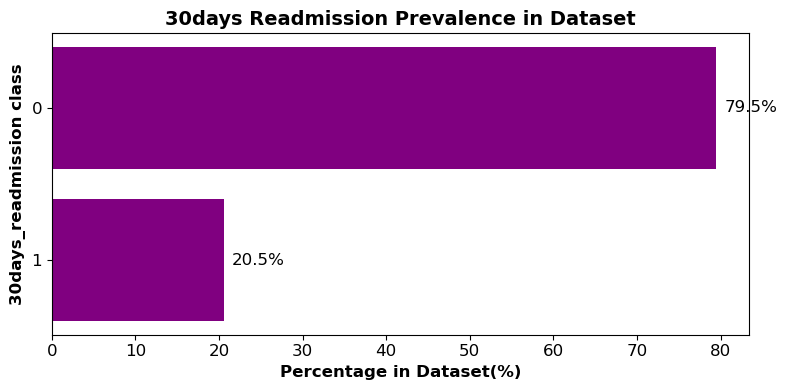

In [164]:
#Exploratory Data Analysis
import matplotlib.pyplot as plt

# Dataset Class Distribution analysis
active_dfplot = active_patients.groupby(["30days_readmission"]).size().reset_index()
active_dfplot.rename(columns = {0 : "Count"}, inplace = True)
active_dfplot["Readmission_class distribution"] = (active_dfplot["Count"]/sum(active_dfplot["Count"]))*100
active_dfplot= active_dfplot.sort_values(by = "Readmission_class distribution", ascending = True)

fig,ax = plt.subplots(figsize =(8,4))
#pos_y = np.arange(len(df["Disease"]))
bars = ax.barh(active_dfplot["30days_readmission"].astype(str),active_dfplot["Readmission_class distribution"], color = "purple")
#formatter = mtick.PercentFormatter(xmax =100)
#ax.xaxis.set_major_formatter(formatter)
ax.set_xlabel("Percentage in Dataset(%)", fontweight = "bold", fontsize = 12)
ax.set_ylabel("30days_readmission class" , fontweight = "bold", fontsize = 12)
ax.set_title("30days Readmission Prevalence in Dataset", fontweight = "bold", fontsize = 14)
ax.tick_params(axis = "x", labelsize = 12)
ax.tick_params(axis = "y", labelsize = 12)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2,
    f"{width:.1f}%",fontsize = 12,
    va="center", ha="left")
    
plt.tight_layout()
plt.show()

The plot above show that our dataset is highly imbalanced with 20.5% positive class representation. This is a common feature of medical datasets and within the typical class imbalance range observed in 30-day readmission datasets. Based on this observation, we will need to address this class imbalance during our model training and evaluation.

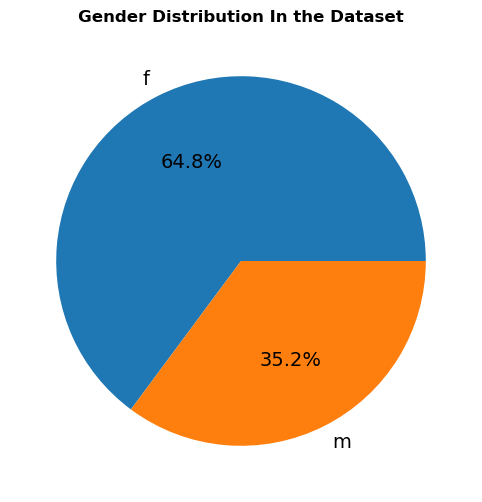

In [166]:
#Dataset distribution by Gender
gender_grp = active_patients.groupby("Gender").size().reset_index()
gender_grp1 = gender_grp.loc[gender_grp["Gender"]!= "o"]
gender_grp1.rename(columns = {0 : "Frequency"},inplace = True)
gender_grp1["Proportion"] = (gender_grp1["Frequency"]/sum(gender_grp1["Frequency"]))*100

fig = plt.figure(figsize=(8,6))
plt.pie(gender_grp1["Proportion"],labels = gender_grp1["Gender"],autopct ="%1.1f%%", textprops = {"fontsize" : 14})
plt.title("Gender Distribution In the Dataset", fontweight= "bold")
plt.show()

The pie chart above shows that 65% of Caryfy caregivers' clients with hospitalization events are females

In [168]:
#create a new dataframe to extract only fall risk data
fallrisk_df =recentfall_df.loc[:,["UUID","DoesClientHaveHistoryOfFalls","HasClientFallenRecently","FallRisk"]]
#print(fallrisk_df.loc[fallrisk_df["FallRisk"].isna()].head())
fallrisk_df["DoesClientHaveHistoryOfFalls"] = np.where(fallrisk_df["DoesClientHaveHistoryOfFalls"].isna(),fallrisk_df["HasClientFallenRecently"],fallrisk_df["DoesClientHaveHistoryOfFalls"])
#fallrisk_df.loc[fallrisk_df["UUID"] == "b80b4025-0507-46cd-91f6-1516fc077ece"]
fallrisk_df["FallRisk"] = np.where(fallrisk_df["FallRisk"].isna(),fallrisk_df["DoesClientHaveHistoryOfFalls"],fallrisk_df["FallRisk"])
fallrisk_df.loc[fallrisk_df["UUID"] == "d74656f4-090e-4402-87d5-c27c1e4db5cd"]

#drop fall risk from active patients dataframe
#active_patients.drop(["FallRisk"],axis = 1, inplace = True)
#active_patients.columns

active_patientsupd = pd.merge(active_patients,fallrisk_df.loc[:,["UUID","FallRisk"]], on = "UUID", how = "left")


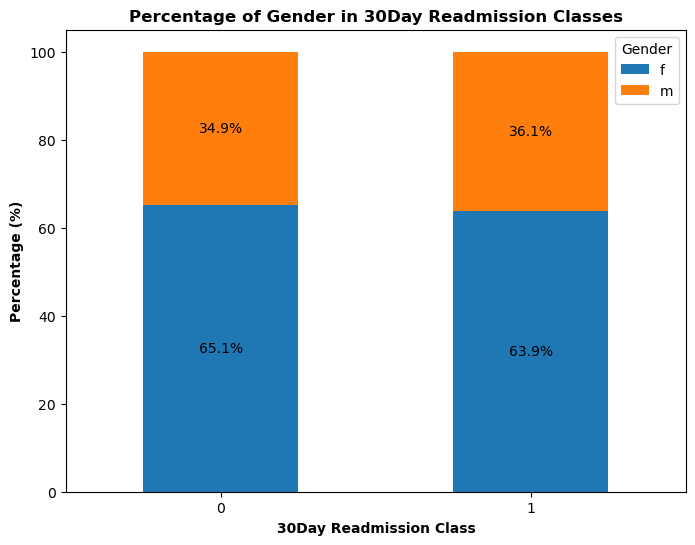

In [169]:
#Gender impact on 30-day readmission risk
gender_df = active_patients.loc[active_patients["Gender"] != "o"]
gender_ct1 = pd.crosstab(gender_df["30days_readmission"],gender_df["Gender"])


gender_percent1 = gender_ct1.div(gender_ct1.sum(axis = 1), axis = 0) *100

#generate plots
ax = gender_percent1.plot.bar(stacked = True, figsize=(8,6), rot = 0)
ax.set_title("Percentage of Gender in 30Day Readmission Classes", fontweight= "bold")
ax.set_xlabel("30Day Readmission Class", fontweight = "bold")
ax.set_ylabel("Percentage (%)",fontweight = "bold")
ax.legend(title = "Gender")
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", label_type= "center")
plt.show()

The gender versus readmission bar chart shows no meaningful association between gender and 30‑day readmission risk.

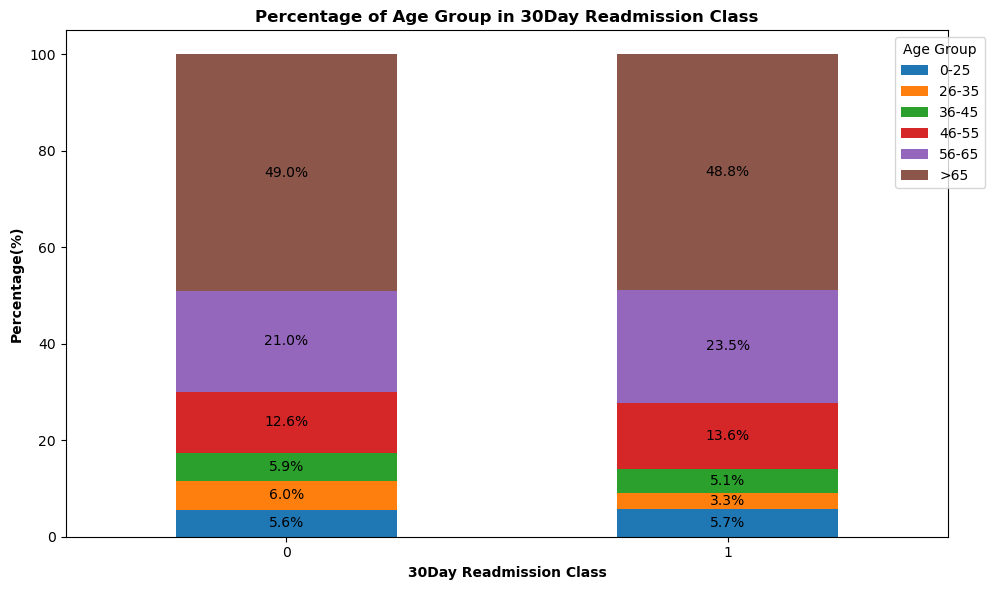

In [171]:
#Age impact on 30-day readmission risk 
age_df = active_patients.loc[active_patients["Age_2025_end"]> 0]
#define age bins and labels
age_bins = [0,25,35,45,55,65,150]
age_labels = ["0-25","26-35","36-45","46-55","56-65",">65"]
age_df["age_group"] = pd.cut(age_df["Age_2025_end"], bins = age_bins, labels = age_labels, right = True)

age_ct = pd.crosstab(age_df["30days_readmission"],age_df["age_group"])
age_pct = age_ct.div(age_ct.sum(axis=1), axis =0)*100

ax = age_pct.plot(kind = "bar", stacked = True, figsize =(10,6))
plt.title("Percentage of Age Group in 30Day Readmission Class",fontweight = "bold")
plt.xlabel("30Day Readmission Class", fontweight = "bold")
plt.ylabel("Percentage(%)", fontweight = "bold")
plt.xticks(rotation=0)
plt.legend(title = "Age Group", bbox_to_anchor =(1.05,1))
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", label_type= "center")

plt.tight_layout()
plt.show()
           


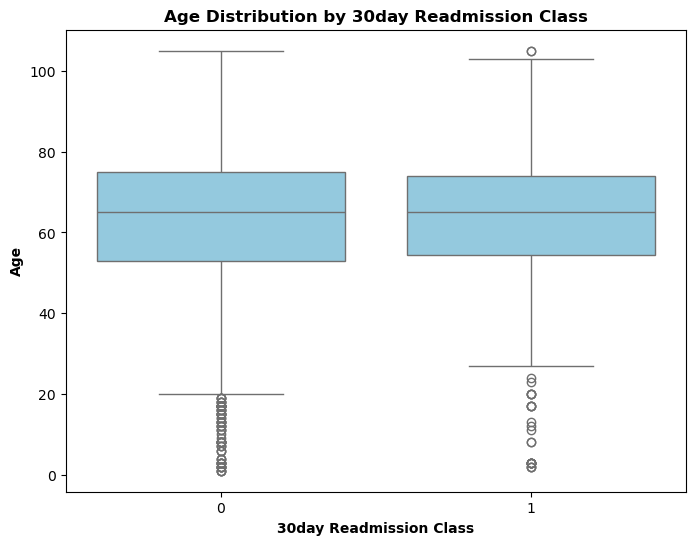

In [172]:
#Boxplot of age
import seaborn as sns
#sns.set_style("whitegrid")
plt.figure(figsize = (8,6))
sns.boxplot(x = "30days_readmission", y = "Age_2025_end", data = age_df, color = "skyblue")
plt.title("Age Distribution by 30day Readmission Class", fontweight = "bold")
plt.xlabel("30day Readmission Class", fontweight = "bold")
plt.ylabel("Age", fontweight = "bold")
plt.show()

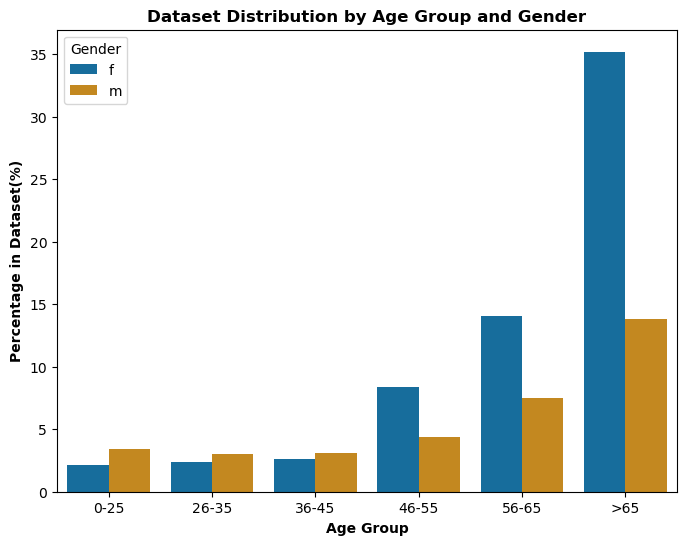

In [173]:
# Dataset age group/ gender distribution
diagplt_df = active_patients.copy()
diagplt_df["age_group"] = pd.cut(age_df["Age_2025_end"], bins = age_bins, labels = age_labels, right = True)

diagplt_df2 = diagplt_df.loc[(diagplt_df["Gender"] != "o")]

#diagplt_df["30days_readmission"].unique()

diagplt_dfplot1 = diagplt_df2.groupby(["age_group","Gender"]).size().reset_index()
diagplt_dfplot1.rename(columns = {0 : "Count"}, inplace = True)
diagplt_dfplot1["Age_Gender distribution"] = (diagplt_dfplot1["Count"]/sum(diagplt_dfplot1["Count"]))*100

#diagplt_dfplot["30days_readmission"]*100

plt.figure(figsize = (8,6))
sns.barplot(data = diagplt_dfplot1, x = "age_group", y = "Age_Gender distribution", hue = "Gender",palette = "colorblind")
plt.title("Dataset Distribution by Age Group and Gender", fontweight = "bold")
plt.xlabel("Age Group", fontweight = "bold")
plt.ylabel("Percentage in Dataset(%)", fontweight = "bold")
plt.show()

Analysis of the age plots reveal the following:
1. Most of Caryfy's caregiver agencies clients with hospitalization records are female and seniors.
2. Despite most admissions occuring in the older age group, age by itself is not a strong predictor of 30-day readmission risk.

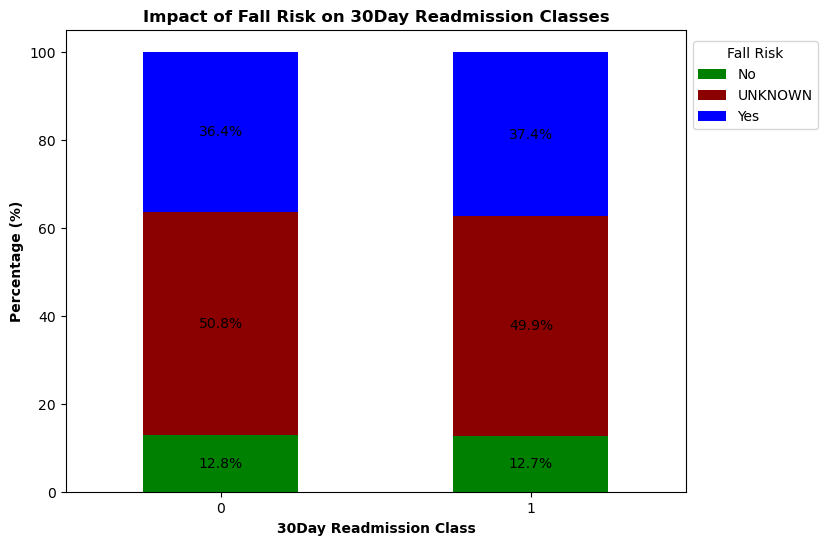

In [175]:
#fall risk impact on 30-day readmission risk

#create a crosstab table
active_patientsupd["FallRisk"] = active_patientsupd["FallRisk"].fillna("UNKNOWN")
fall_ct = pd.crosstab(active_patientsupd["30days_readmission"],active_patientsupd["FallRisk"])


fall_pct = fall_ct.div(fall_ct.sum(axis = 1), axis = 0) *100

#generate plots
colors = ["green","darkred","blue"]
ax = fall_pct.plot.bar(stacked = True, figsize=(8,6), rot = 0, color = colors)
ax.set_title("Impact of Fall Risk on 30Day Readmission Classes",fontweight = "bold")
ax.set_xlabel("30Day Readmission Class", fontweight = "bold")
ax.set_ylabel("Percentage (%)",fontweight = "bold")
ax.legend(title = "Fall Risk",loc = "center left", bbox_to_anchor = (1, 0.88))
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", label_type= "center")
plt.show()


Due to the high number of missing values in the fall risk dataset, the impact of fall risk on 30-day readmission risk is inconclusive.

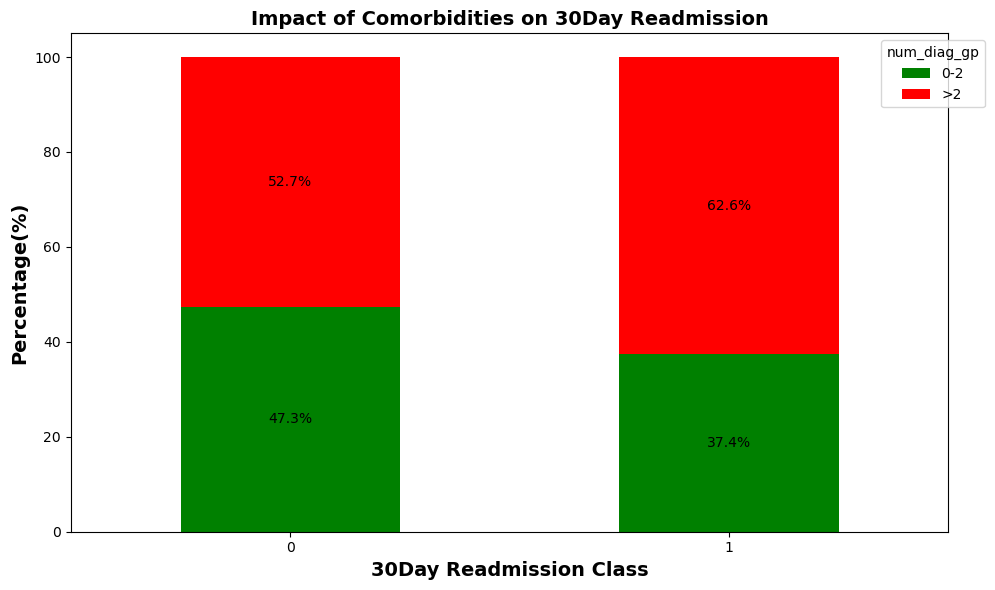

In [177]:
#Impact of comorbidities on 30-day readmission risk
diagplt_df = active_patients.copy()
#define diagnosis bins and labels
diag_bins = [0,2,50]
diag_labels = ["0-2",">2"]
diagplt_df["num_diag_gp"] = pd.cut(diagplt_df["num_known_diagnosis"], bins = diag_bins, labels = diag_labels, right = True)

diag_ct = pd.crosstab(diagplt_df["30days_readmission"],diagplt_df["num_diag_gp"])
diag_pct = diag_ct.div(diag_ct.sum(axis=1), axis =0)*100

colors = ["green","red"]
ax = diag_pct.plot(kind = "bar", stacked = True, figsize =(10,6), color = colors)
plt.title("Impact of Comorbidities on 30Day Readmission", fontweight = "bold", fontsize = 14)
plt.xlabel("30Day Readmission Class", fontweight = "bold", fontsize = 14)
plt.ylabel("Percentage(%)",fontweight = "bold", fontsize = 14)
plt.xticks(rotation=0)
plt.legend(title = "num_diag_gp", bbox_to_anchor =(1.05,1))
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", label_type= "center")

plt.tight_layout()
plt.show()

Analysis of the comorbidities plot shows a 10% increase in 30-day readmission rate when patients have more than 2 diseases suggesting that comorbidities may be a strong predictor of 30-day readmission risk.

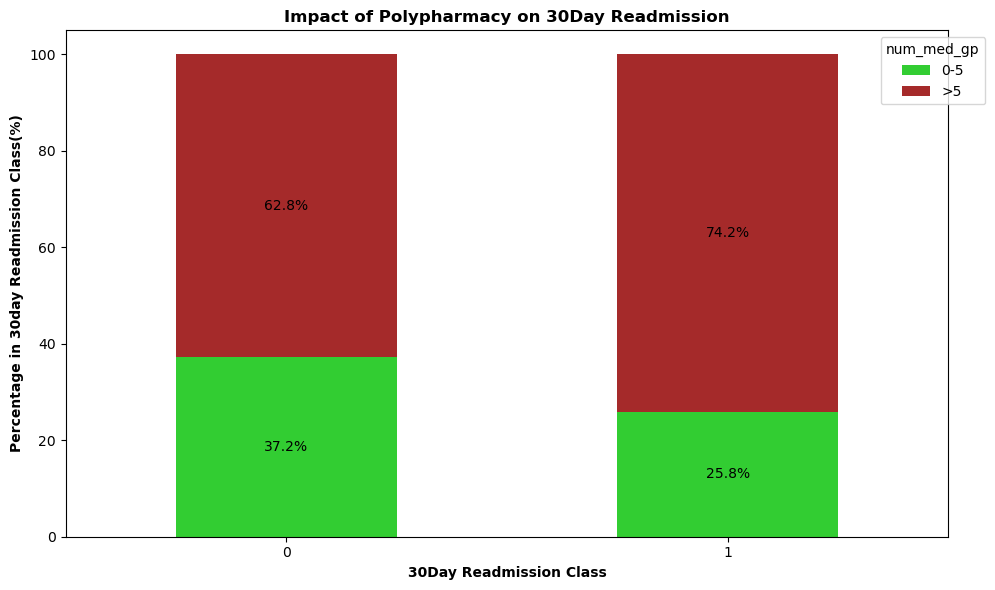

In [179]:
#Polypharmacy impact on 30-day readmission risk
medplt_df = diagplt_df.copy()
#define diagnosis bins and labels
med_bins = [0,5,30]
med_labels = ["0-5",">5"]
medplt_df["num_med_gp"] = pd.cut(medplt_df["num_meds"], bins = med_bins, labels = med_labels, right = True)

med_ct = pd.crosstab(medplt_df["30days_readmission"],medplt_df["num_med_gp"])
med_pct = med_ct.div(med_ct.sum(axis=1), axis =0)*100

colors = ["limegreen","brown"]
ax = med_pct.plot(kind = "bar", stacked = True, figsize =(10,6), color = colors)
plt.title("Impact of Polypharmacy on 30Day Readmission",fontweight = "bold")
plt.xlabel("30Day Readmission Class", fontweight = "bold")
plt.ylabel("Percentage in 30day Readmission Class(%)", fontweight = "bold")
plt.xticks(rotation=0)
plt.legend(title = "num_med_gp", bbox_to_anchor =(1.05,1))
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", label_type= "center")

plt.tight_layout()
plt.show()

Analysis of the polypharmacy plot shows a 12% increase in 30-day readmission rate among patients taking more than 5 medications concurrently, suggesting that polypharmacy may be a slightly stronger predictor of 30-day readmission risk than comorbidities.

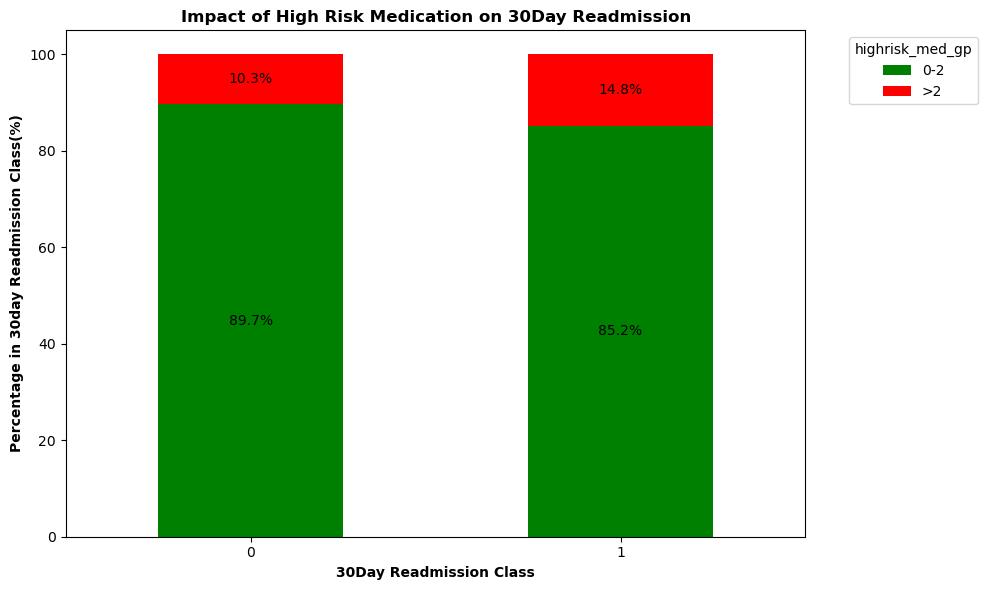

In [181]:
#High risk med risk impact on 30-day readmission risk
medrisk_bins = [0,2,10]
medrisk_labels = ["0-2",">2"]
medplt_df["highrisk_med_gp"] = pd.cut(medplt_df["high_risk_med_count"], bins = medrisk_bins, labels = medrisk_labels, right = True)

medrisk_ct = pd.crosstab(medplt_df["30days_readmission"],medplt_df["highrisk_med_gp"])
medrisk_pct = medrisk_ct.div(medrisk_ct.sum(axis=1), axis =0)*100

colors = ["green","red"]
ax = medrisk_pct.plot(kind = "bar", stacked = True, figsize =(10,6), color = colors)
plt.title("Impact of High Risk Medication on 30Day Readmission", fontweight = "bold")
plt.xlabel("30Day Readmission Class", fontweight = "bold")
plt.ylabel("Percentage in 30day Readmission Class(%)", fontweight = "bold")
plt.xticks(rotation=0)
plt.legend(title = "highrisk_med_gp", bbox_to_anchor =(1.05,1))
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", label_type= "center")

plt.tight_layout()
plt.show()

Taking more than 2 high risk medications concurrently seems to have a slight impact on 30-day readmission risk.

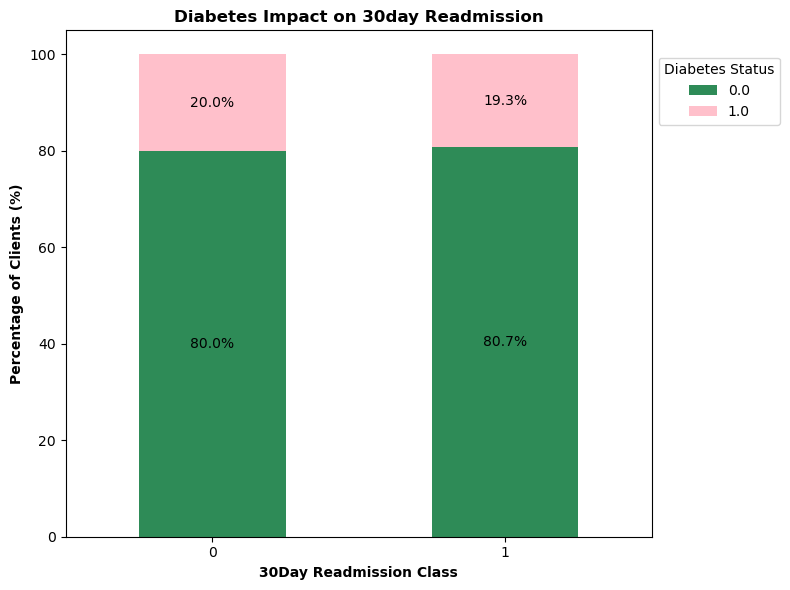

In [183]:
# Specific diseases impact on 30-day readmission risk
#create a crosstab table
diab_ct1 = pd.crosstab(diagplt_df["30days_readmission"],diagplt_df["has_diabetes"])


diab_percent1 = diab_ct1.div(diab_ct1.sum(axis = 1), axis = 0) *100

#generate plots
colors = ["seagreen","pink"]
ax = diab_percent1.plot.bar(stacked = True, figsize=(8,6), rot = 0, color = colors)
ax.set_title("Diabetes Impact on 30day Readmission", fontweight = "bold")
ax.set_xlabel("30Day Readmission Class",fontweight = "bold")
ax.set_ylabel("Percentage of Clients (%)", fontweight = "bold")
ax.legend(title = "Diabetes Status",loc = "center left", bbox_to_anchor = (1, 0.88))
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", label_type= "center")

plt.tight_layout()
plt.show()


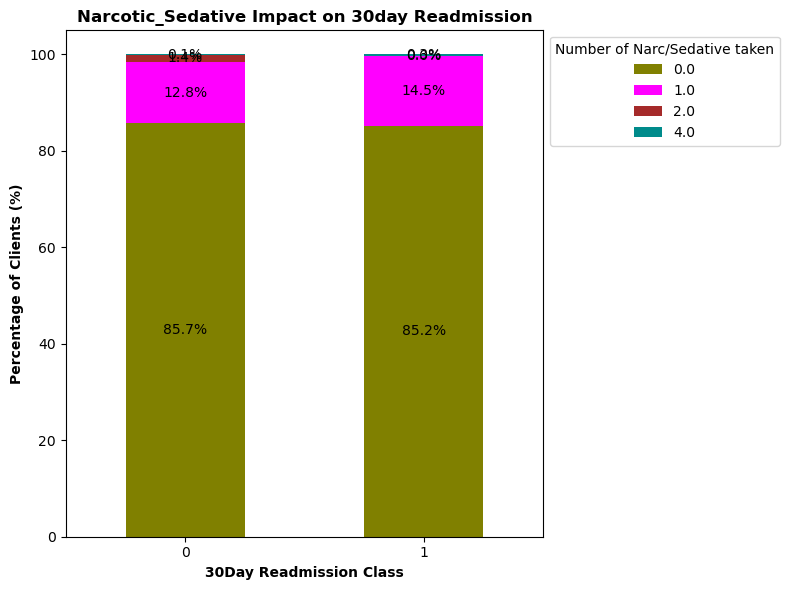

In [184]:
#Specific high risk medication class relationship with 30-day readmission risk
#create a crosstab table
narc_ct1 = pd.crosstab(diagplt_df["30days_readmission"],diagplt_df["is_narcotic_sedative"])


narc_percent = narc_ct1.div(narc_ct1.sum(axis = 1), axis = 0) *100

#generate plots
colors = ["olive","magenta","brown","darkcyan"]
ax = narc_percent.plot.bar(stacked = True, figsize=(8,6), rot = 0,color = colors)
ax.set_title("Narcotic_Sedative Impact on 30day Readmission", fontweight = "bold")
ax.set_xlabel("30Day Readmission Class", fontweight = "bold")
ax.set_ylabel("Percentage of Clients (%)", fontweight = "bold")
ax.legend(title = "Number of Narc/Sedative taken",loc = "center left", bbox_to_anchor = (1, 0.88))
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f%%", label_type= "center")

plt.tight_layout()
plt.show()


Analysis of diabetes or narcotics sedative meds impact of 30-day readmission risk show weak relationships which may give credence to the need to engineer new features from these types of features to boost their signal and enhance their predictive power. 

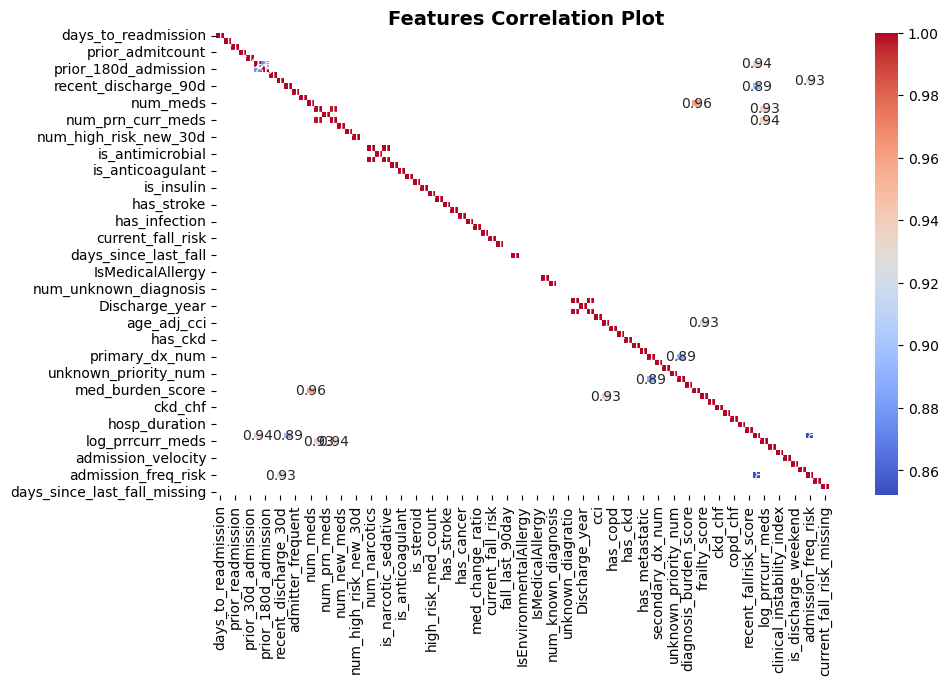

In [186]:
#check for multicolinearity: Multicolinearity plot limited to only highly correlated features
corr_feat = active_patients.corr(numeric_only = True)
high_corr = corr_feat[(corr_feat >= 0.85) & ( corr_feat <=1)]

import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plt.title("Features Correlation Plot", fontweight = "bold", fontsize = 14)
plt.show()

To aid visualization, the correlation plot shown above was limited to just highly correlated features. Analysis of the features correlation plot revealed that our dataset contains some highly correlated features and in depth analysis of these features shows expected behavior among these features for example having high correlation between admission_freq_risk and recent_discharge_30d makes sense since both features measure recent utilization intensity. Similar patterns were also observed across the other highly correlated features. This observation confirms that our features,both raw and engineered, are behaving as expected. To address multicollinearity, appropriate regularization techniques were applied during model training.

## 5.0 Model Training and Evaluation   
Two predictive models were trained and evaluated. A logistic regression model, trained on a subset of features, served as the baseline to quantify performance gains achieved by the CatBoost model. The model development process was broken into the following main steps:

1. Train and Test datasets split
2. Expanding window Cross validation on the Train dataset
3. Model hyperparameter tuning
4. Final model training
5. Final model evaluation

The code blocks below illustrate how both models were trained and evaluated using these four steps.



**Model features selection**

Before training, relevant features were identified and grouped into appropriate categories, as CatBoost requires explicit specification of categorical features. To prevent data leakage, features that expose future information such as hospitalization and discharge dates, UUIDs, days to readmission, and next admission were excluded. A total of 72 features were selected for training the CatBoost model and a subset of these features was used to build the baseline Logistic model. Details about this subset is provided in the Logistic Regression model development sections.

In [190]:
#Select features needed for model training and split them into categories

features_numeric = ['prior_readmission','prior_admitcount', 'prior_30d_admission',
       'prior_90d_admission', 'prior_180d_admission', 'num_meds',
       'num_current_meds', 'num_prn_meds', 'num_prn_curr_meds', 'num_new_meds',
       'inj_meds_count', 'num_high_risk_new_30d', 'num_antibiotics_last_14d',
       'num_narcotics','is_antimicrobial', 'is_narcotic_sedative',
       'is_chemotherapy', 'is_anticoagulant', 'is_antipsychotic', 'is_steroid',
       'is_insulin', 'high_risk_med_count', 'med_change_ratio', 'Total_allergies',
       'num_known_diagnosis', 'num_unknown_diagnosis','unknown_diagratio','cci','age_adj_cci',
       'primary_dx_num', 'secondary_dx_num','tertiary_dx_num', 'unknown_priority_num',
       'prior_weighted_dx_burden', 'diagnosis_burden_score','med_burden_score', 'frailty_score', 
       'high_risk_med_expo','hosp_duration','Age_adjusted','days_since_last_discharge','clinical_instability_index','admission_velocity',
        'log_prior90d_admission','chronic_disease_count','days_since_last_fall']
features_binary = ['has_afib', 'has_stroke',
       'has_diabetes', 'has_cancer', 'has_infection','polypharmacy_flag','current_fall_risk', 'fallen_ever',
       'fall_last_90day','IsEnvironmentalAllergy','IsFoodAllergy', 'IsMedicalAllergy','has_copd', 'has_chf', 
       'has_ckd', 'has_diabetes_comp','has_metastatic','ckd_chf','diabcomp_ckd', 'copd_chf','days_since_last_fall_missing',
        'primary_dx_3dig_missing', 'current_fall_risk_missing','admitter_frequent','is_discharge_weekend']         
        
features_cat = ['Gender']


                    
                    

### 5.0.1 Logistic Regression Model(Baseline) Training and Evaluation

Training the logistic regression model began with splitting the dataset into training and test sets using a time‑based approach, reflecting the forward‑looking nature of 30‑day readmission prediction. This strategy mimics real‑world deployment and prevents temporal data leakage for example, using a December 2024 readmission to predict an October 2024 outcome. Because predictions are made at discharge, the discharge date was used as the split criterion, with an 80/20 train–test split determined by the 80th percentile of discharge dates. To further improve generalization, patients in the training set were excluded from the test set, ensuring the model learned population‑level patterns rather than memorizing individual patient histories. The code blocks below illustrate these steps, along with some initial preprocessing done.

In [193]:
#make a copy of the orginal starting dataset and sort in preparation for splitting
active_patients_log = active_patients.copy()
logistic_df = active_patients_log.sort_values("DischargeDate").reset_index(drop=True)


#### 5.0.1.1 Train-Test Split

Because the logistic regression model served as a baseline heuristic, only three features were used. To prevent breakdown of the logistic regression equation, missing data in these selected features were imputed with values that were deemed appropriate for example, missing values in num_know_diagnosis were set to zero, based on the rationale that clinically significant diagnoses are unlikely to go undocumented.

In [195]:
#define Logistic Regression model target and select subset of features needed  
target = "30days_readmission"
featnum_log = ["Age_adjusted","num_known_diagnosis"]
featcat_log = ["Gender"]
features_log = featnum_log + featcat_log


#Impute missing data before seperating into X and Y datasets
logistic_df["num_known_diagnosis"] = logistic_df["num_known_diagnosis"].fillna(0)

logistic_df["Gender"] = logistic_df["Gender"].fillna("UNKNOWN")

In [196]:
#time split dataset using 80%/20% split

holdout_ratio = 0.2

split_datelog = logistic_df["DischargeDate"].quantile(1-holdout_ratio)

train_df = logistic_df[logistic_df["DischargeDate"] < split_datelog]
test_df = logistic_df[logistic_df["DischargeDate"] >= split_datelog]

# remove clients that exist in train dataset from test dataset
trainlog_cli = set(train_df["UUID"].unique())
testlog_df = test_df[~test_df["UUID"].isin(trainlog_cli)]
print(len(train_df))
print(len(testlog_df))

1769
319


In [197]:
#Create X-train, y_train, X_test, y_test datasets
X_train = train_df[features_log]
y_train = train_df[target]
X_test = testlog_df[features_log]
y_test = testlog_df[target]


In [198]:
#Scale only the numeric features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline



In [199]:
#Define the Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


#### 5.0.1.2 Cross validation : Expanding window

Given our small dataset size (2215 observations), expanding window cross-validation was used instead of rolling window cross-validation. Expanding window cross-validation is a time aware validation strategy where the training data grows over time and validation is always done on the next future chunk of data. Instead of randomly splitting your data, the time aspect of 30-day readmission prediction is respected by training on earlier data and validating on later data, for example if you divide your train dataset into 2 folds, the fold split may look like this

Fold 1
    
    Train: Jan-Mar 
    
    Validate : Apr

Fold 2
    
    Train: Jan-Apr
    
    Validate : May
    
To prevent patient leakage and improve model generalization, within each fold,patients included in the training set were excluded from the validation set during the cross‑validation folds creation. The code blocks below illustrate how these cross‑validation folds were constructed from the training dataset.  

In [201]:
#create expanding window cv that prevent patient leakage
from sklearn.metrics import roc_auc_score
def window_splits_expanding(df, n_splits = 5, date_col= "DischargeDate"):
    df = df.sort_values(date_col).reset_index(drop=True)
    unique_dates = df[date_col].sort_values().unique()
    fold_size = len(unique_dates)//(n_splits +1)
    splits = []
    for i in range(1, n_splits+1):
        train_end = unique_dates[i * fold_size]
        
        val_end = unique_dates[(i+1) * fold_size] if (i+1)* fold_size < len(unique_dates) else unique_dates[-1]
        
        train_idx = df[df[date_col] <= train_end].index
        val_idx = df[(df[date_col] > train_end) & ( df[date_col] <= val_end)].index
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]
        #remove patient leakage inside fold
        train_clients = set(train_df["UUID"])
        val_df = val_df[~val_df["UUID"].isin(train_clients)]
        splits.append((train_df.index,val_df.index))
    return splits    

#### 5.0.1.3 Model Hyperparameter Tuning

After constructing the expanding‑window cross‑validation folds, an Optuna study was used to identify hyperparameters that maximized ROC-AUC. Given our dataset class imbalance, ROC-AUC served as the primary model selection metric. To assess ROC-AUC variability across folds, the CV ROC-AUC standard deviation was tracked. Class imbalance strategies and regularization was implemented to address class imbalance,overfitting, and the multicollinearity issues identified in the EDA section. Values across the L1 to L2 spectrum were tested during the optuna study to determine the optimal setting for the final logistic regression model. The setup and results are shown below.

In [203]:
#Run Optuna and time series cross validation
from sklearn.metrics import roc_auc_score
import numpy as np
import optuna
splits_log = window_splits_expanding(df= train_df , n_splits = 5, date_col= "DischargeDate")

def objective_lr(trial):
    c_param = trial.suggest_float("C", 1e-4, 10, log = True)
    l_ratio = trial.suggest_float("l1_ratio",0,1)
    preprocessor = ColumnTransformer(transformers = [("num", StandardScaler(),featnum_log),
                                                ("cat", OneHotEncoder(handle_unknown="ignore",drop="first"),featcat_log)
                                                ])
    pipeline = Pipeline([("preprocess",preprocessor),
                     ("model", LogisticRegression(C = c_param, l1_ratio =l_ratio ,solver = "saga",
                         class_weight = "balanced", 
                         max_iter = 2000, random_state = 15))])
    


    auc_scoresls = []
    for train_idx, val_idx in splits_log:
        trainlog_df = train_df.iloc[train_idx]
        vallog_df = train_df.iloc[val_idx]
        X_trlog = trainlog_df[features_log]
        y_trlog = trainlog_df[target]
        X_vallog = vallog_df[features_log]
        y_vallog = vallog_df[target]
        #check for folds with only one class in the target column
        if y_trlog.nunique()<2:
            continue
        if y_vallog.nunique()<2:
            continue   
        pipeline.fit(X_trlog, y_trlog)
        prediction = pipeline.predict_proba(X_vallog)[:,1]
        auc = roc_auc_score(y_vallog,prediction)
        auc_scoresls.append(auc)
    validation_auc_std = np.std(auc_scoresls)
    
    trial.set_user_attr("validation_auc_std",validation_auc_std)    
    print("5 Fold Logistic Regression Cross-Validation AUC: " , np.mean(auc_scoresls)) 
    print("5 Fold Logistic Regression Cross-Validation AUC Std: " , np.std(auc_scoresls))
    return np.mean(auc_scoresls)

In [204]:
#Run optuna
sampler_lr = optuna.samplers.TPESampler(seed=15)
study_lr = optuna.create_study(direction = "maximize", sampler = sampler_lr)
study_lr.optimize(objective_lr, n_trials=40)
print("Best Logistic Regression AUC:", study_lr.best_value)
print("Best Logistic Regression params:")
print(study_lr.best_params)

[I 2026-04-15 23:11:21,474] A new study created in memory with name: no-name-89c241f9-99b3-47e7-9615-f4cc1c602bcc
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:21,523] Trial 0 finished with value: 0.510157966560947 and parameters: {'C': 1.7542378867251793, 'l1_ratio': 0.17889592492099848}. Best is trial 0 with value: 0.510157966560947.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:21,554] Trial 1 finished with value: 0.5 and parameters: {'C': 0.00018698900537392134, 'l1_ratio': 0.36153844608822294}. Best is trial 0 with value: 0.510157966560947.
/opt/anaconda3

5 Fold Logistic Regression Cross-Validation AUC:  0.510157966560947
5 Fold Logistic Regression Cross-Validation AUC Std:  0.06781598708854608
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.508522755776344
5 Fold Logistic Regression Cross-Validation AUC Std:  0.06794672281648441
5 Fold Logistic Regression Cross-Validation AUC:  0.5040146165628524
5 Fold Logistic Regression Cross-Validation AUC Std:  0.06395077634242213


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:21,760] Trial 7 finished with value: 0.5110051640095012 and parameters: {'C': 1.0849192404113777, 'l1_ratio': 0.21055058265882798}. Best is trial 7 with value: 0.5110051640095012.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:21,796] Trial 8 finished with value: 0.5 and parameters: {'C': 0.0006858279137616918, 'l1_ratio': 0.04670639168207169}. Best is trial 7 with value: 0.5110051640095012.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in c

5 Fold Logistic Regression Cross-Validation AUC:  0.5110051640095012
5 Fold Logistic Regression Cross-Validation AUC Std:  0.06851858148358123
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5000892764762187
5 Fold Logistic Regression Cross-Validation AUC Std:  0.07449617788593144
5 Fold Logistic Regression Cross-Validation AUC:  0.5073406187354406
5 Fold Logistic Regression Cross-Validation AUC Std:  0.06858567226832821


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:21,983] Trial 12 finished with value: 0.5111168483673041 and parameters: {'C': 0.8703945938493383, 'l1_ratio': 0.7098750914229843}. Best is trial 12 with value: 0.5111168483673041.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:22,018] Trial 13 finished with value: 0.5096600693281526 and parameters: {'C': 0.6539915716883612, 'l1_ratio': 0.7459284925957926}. Best is trial 12 with value: 0.5111168483673041.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown c

...

5 Fold Logistic Regression Cross-Validation AUC:  0.5327767257703563
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0655534515407127
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5327767257703563
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0655534515407127
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5033683051211767
5 Fold Logistic Regression Cross-Validation AUC Std:  0.06493746053600227
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.503977787482367
5 Fold Logistic Regression Cross-Validation AUC Std:  0.09748148644972511


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:22,441] Trial 26 finished with value: 0.503977787482367 and parameters: {'C': 0.01251719317593663, 'l1_ratio': 0.6425026827767558}. Best is trial 18 with value: 0.5327767257703563.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:22,472] Trial 27 finished with value: 0.5 and parameters: {'C': 0.001626289568254695, 'l1_ratio': 0.5125832741590732}. Best is trial 18 with value: 0.5327767257703563.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in 

5 Fold Logistic Regression Cross-Validation AUC:  0.503977787482367
5 Fold Logistic Regression Cross-Validation AUC Std:  0.09748148644972511
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5327767257703563
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0655534515407127
5 Fold Logistic Regression Cross-Validation AUC:  0.5137069065379807
5 Fold Logistic Regression Cross-Validation AUC Std:  0.06697215224875772
5 Fold Logistic Regression Cross-Validation AUC:  0.5043735422783848
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0860540189337621
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.503977787482367
5 Fold Logistic Regression Cross-Validation AUC Std:  0.09748148644972511


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:22,670] Trial 33 finished with value: 0.5 and parameters: {'C': 0.000682749770501344, 'l1_ratio': 0.5530413190897429}. Best is trial 18 with value: 0.5327767257703563.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-04-15 23:11:22,701] Trial 34 finished with value: 0.5 and parameters: {'C': 0.0023027274634450016, 'l1_ratio': 0.34327093520228913}. Best is trial 18 with value: 0.5327767257703563.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0]

5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5327767257703563
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0655534515407127
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
5 Fold Logistic Regression Cross-Validation AUC:  0.503977787482367
5 Fold Logistic Regression Cross-Validation AUC Std:  0.09748148644972511
5 Fold Logistic Regression Cross-Validation AUC:  0.5
5 Fold Logistic Regression Cross-Validation AUC Std:  0.0
Best Logistic Regression AUC: 0.5327767257703563
Best Logistic Regression params:
{'C': 0.010352013932440866, 'l1_ratio': 0.5848888221710449}


In [205]:
best_triallog = study_lr.best_trial
best_cvstd = best_triallog.user_attrs["validation_auc_std"]
print(f"Logistic Regression CV AUC Standard deviation : {best_cvstd}")

Logistic Regression CV AUC Standard deviation : 0.0655534515407127


#### 5.0.1.4 Final Model Training and Evaluation

In the final step, the logistic regression model was trained on the full training dataset using the optimal hyperparameters identified through the Optuna study. The final model was then evaluated on both the training and test datasets. To assess generalization to unseen data, two test sets were used: one containing entirely new patients and another comprising a mix of previously seen and new patients. The evaluation results are presented below.

In [207]:
#Train logistic regression model on all training dataset and calculate train auc
best_preprocessor = ColumnTransformer(transformers = [("num", StandardScaler(),featnum_log),
                                                ("cat", OneHotEncoder(handle_unknown="ignore", drop = "first"),featcat_log)
                                                ])

final_model_lr = LogisticRegression(**study_lr.best_params,
                                    solver = "saga",
                                    class_weight = "balanced",
                                    max_iter = 2000,
                                    random_state = 15)
final_baseline_pipeline = Pipeline(steps=[("preprocessor", best_preprocessor),
                                          ("classifier", final_model_lr)])
final_baseline_pipeline.fit(X_train, y_train)

predslog_train = final_baseline_pipeline.predict_proba(X_train)[:,1]
auc_logtrain = roc_auc_score(y_train, predslog_train)
print(f" Logistic Regression Train AUC: {auc_logtrain}")



 Logistic Regression Train AUC: 0.5803497324855869


In [208]:
#Calculate Test AUC(New Patients)
predslog_test = final_baseline_pipeline.predict_proba(X_test)[:,1]
auc_logtest = roc_auc_score(y_test, predslog_test)
print(f" Logistic Regression Test AUC(New Patients): {auc_logtest}")

 Logistic Regression Test AUC(New Patients): 0.45720172316913277


In [209]:
#Calculate Test AUC(All Patients)
predslog_testall = final_baseline_pipeline.predict_proba(test_df[features_log])[:,1]
auc_logtestall = roc_auc_score(test_df[target], predslog_testall)
print(f" Logistic Regression Test AUC(All Patients): {auc_logtestall}")

 Logistic Regression Test AUC(All Patients): 0.4793816569273488


### 5.0.2 CatBoost Model Training and Evaluation

The CatBoost model was trained using all 72 features, applying the same time‑based split and five‑fold expanding‑window cross‑validation strategy used for the logistic regression model. An Optuna study was also conducted to identify the optimal hyperparameters for this model. The code blocks below detail the steps used to train and evaluate the CatBoost model.

In [211]:
#Train CatBoost model
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, average_precision_score


In [212]:
#Select features needed for training
feat_cattotal = features_cat 
feat = features_numeric + features_binary + features_cat 


In [213]:
#Make a copy of the original dataset and sort in preparation for splitting
cat_df = active_patients.copy()

cat_df = cat_df.sort_values("DischargeDate").reset_index(drop=True)


In [214]:
#preprocessing needed for categorical features
for col in feat_cattotal:
    cat_df[col] = (cat_df[col].fillna("UNKNOWN").astype(str).str.strip())
    

#### 5.0.2.1 CatBoost Model Train-Test Split

In [216]:
#time split dataset based on 80%/20% train /test split
holdout_ratio = 0.2

split_date = cat_df["DischargeDate"].quantile(1-holdout_ratio)

traincat_df = cat_df[cat_df["DischargeDate"] < split_date]
testcat_df = cat_df[cat_df["DischargeDate"] >= split_date]

#remove patients in train dataset from test dataset to prevent patient leakage
train_cli = set(traincat_df["UUID"].unique())
testcat_dfblind = testcat_df[~testcat_df["UUID"].isin(train_cli)]


In [217]:
X_traincat = traincat_df[feat]
y_traincat = traincat_df[target]
X_testcat = testcat_dfblind[feat]
y_testcat = testcat_dfblind[target]
X_testcatall = testcat_df[feat]
y_testcatall = testcat_df[target]

In [218]:
#Check for class imbalance across datasets
test_posrate = y_testcat.mean()
print(f"test dataset(new patients) class imbalance : {test_posrate}")
train_posrate = y_traincat.mean()
print(f"train_dataset class imbalance : {train_posrate}")

test dataset(new patients) class imbalance : 0.11912225705329153
train_dataset class imbalance : 0.22159412097230075


In [219]:
test_posrateall = y_testcatall.mean()
print(f"test dataset all clients class imbalance : {test_posrateall}")


test dataset all clients class imbalance : 0.1412556053811659


In [220]:
#Identify Categorical features for CatBoost
cat_featidx = [X_traincat.columns.get_loc(col) for col in feat_cattotal]
cat_features = X_traincat.select_dtypes(include = ["object","category"]).columns.tolist()


/var/folders/51/32q7pybd6hn6pgm_7hg6w6780000gn/T/ipykernel_53678/3697557416.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_traincat.select_dtypes(include = ["object","category"]).columns.tolist()


#### 5.0.2.2 CatBoost Model Hyperparameter Tuning

The same expanding‑window approach used to generate five cross‑validation folds for the logistic regression model was applied to the CatBoost model. Hyperparameter tuning was conducted using an Optuna study, during which both cross‑validation AUC standard deviation and the optimal number of boosting iterations per fold were tracked. The average of these optimal iterations was used during final training to reduce overfitting. Class imbalance strategies and L2 regularization were also applied during final training to address class imbalance, multicollinearity and overfitting, with optimal values selected based on the Optuna study results. To diagnose overfitting, learning curves were generated and the optimal iteration for each fold was overlaid on each plot. The setup and results of these steps are shown below.

In [222]:
#function to plot learning curves
def plot_learning_curves(cv_models, eval_metric = "Logloss"):
    n_folds = len(cv_models)
    #create grid of subplots
    cols = 2
    rows = (n_folds + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize = (12, 4 * rows))
    axes = axes.flatten()
    for i, model in enumerate(cv_models):
        evals_result = model.evals_result_
        train_scores = evals_result["learn"][eval_metric]
        val_scores = evals_result["validation"][eval_metric]
        iterations = range(1, len(train_scores) +1)
        ax = axes[i]
        ax.plot(iterations, train_scores, label = f" Training {eval_metric}", color = "blue",linewidth = 2)
        ax.plot(iterations, val_scores, label = f" Validation {eval_metric}", color = "orange",linewidth = 2)
        #Mark the early stopping point
        best_iter = model.get_best_iteration()
        ax.axvline(x=best_iter, color = "darkgreen", linestyle = "--", label = f"Best Iteration ({best_iter})", alpha = 0.7)
        ax.set_title(f" Fold{i+1} Learning Curves", fontsize = 14, fontweight = "bold", pad = 15)
        ax.set_xlabel("Number of Trees", fontsize = 12)
        ax.set_ylabel(eval_metric,fontsize= 12)
        ax.grid(True, linestyle ="--", alpha = 0.3)
        ax.legend(loc="upper right", fontsize = 12, framealpha=1.0)
      #Hide any unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    #fig.savefig("learning_curves.png", bbox_inches = "tight", dpi =300)
    plt.show()



In [223]:
#standalone function to run CV and calculate AUC (Used for LOFO)
def run_cv(df, features, target, splits, params, debug=False):
    aucs = []
    best_iteration = []
    skipped_folds = 0
    for i, (train_ind,val_ind) in enumerate(splits):
        train_df = df.iloc[train_ind]
        val_df = df.iloc[val_ind]
        X_trcatexp = train_df[features]
        y_trcatexp = train_df[target]
        X_valcatexp = val_df[features]
        y_valcatexp = val_df[target]
        #check for folds with only one class in the target column
        if y_trcatexp.nunique()<2:
            if debug:
                print(f"Fold {i} skipped (train fold has only 1 class)")
            skipped_folds +=1
            continue
        if y_valcatexp.nunique()<2:
            if debug:
                print(f"Fold {i} skipped (validation fold has only 1 class)")
            skipped_folds +=1
            continue   
        train_pool = Pool(X_trcatexp, y_trcatexp, cat_features = cat_features)
        val_pool = Pool(X_valcatexp,y_valcatexp,cat_features = cat_features)
        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set = val_pool,early_stopping_rounds = 50)
        best_iters = model.get_best_iteration()
        best_iteration.append(best_iters)
        preds_exp = model.predict_proba(X_valcatexp)[:,1]
        auc = roc_auc_score(y_valcatexp, preds_exp)
        
        #model = CatBoostClassifier(**params)
        #model.fit(X_trcatexp,y_trcatexp)
        #preds_exp = model.predict_proba(X_valcatexp)[:,1]
        #auc = roc_auc_score(y_valcatexp,preds_exp)
        aucs.append(auc)
        #Debug logic
        if debug:
            val_size = len(y_valcatexp)
            pos_rate = y_valcatexp.mean()
            print(f"Fold{i} | AUC : {auc:.4f} | Size : {val_size} | Class imbalance : {pos_rate}")
    if debug:
        print("\n Summary:")
        print(f" Valid folds: {len(aucs)}")
        print(f" Mean_AUC : {np.mean(aucs)}")
        print(f"AUC Std : {np.std(aucs)}")
    return np.mean(aucs), np.std(aucs)  

In [224]:
#Perform Optuna study to determine best CatBoost hyperparameters; define optuna objective function
splits = window_splits_expanding(df= traincat_df , n_splits = 5, date_col= "DischargeDate")

def objective_cat(trial,features, target,splits):
    #clinical_constraints = {"prior_180d_admission":1,
                            #"age_adj_cci":1,
                            #"Age_adjusted": 1}
                                                               
    
    params = { "iterations": trial.suggest_int("iterations", 300, 2000),
              "depth": trial.suggest_int("depth",4,10),
              #"max_ctr_complexity": trial.suggest_int("max_ctr_complexity",1,2),
              #"min_data_in_leaf": trial.suggest_int("min_data_in_leaf",100,200),
              "learning_rate":trial.suggest_float("learning_rate", 0.01,0.2, log = True),
              "l2_leaf_reg":trial.suggest_float("l2_leaf_reg",15,20),
              "random_strength":trial.suggest_float("random_strength", 1e-3,10,log = True),
              "bagging_temperature":trial.suggest_float("bagging_temperature",1,5),
              "border_count": trial.suggest_int("border_count",32,128),
              "loss_function": "Logloss",
              "eval_metric": "AUC",
              "random_seed": 15,
              "auto_class_weights": "SqrtBalanced",
              #"monotone_constraints": clinical_constraints,
              "verbose": False }
    aucs = []
    best_iteration = []
    skipped_folds = 0
    for i, (train_ind,val_ind) in enumerate(splits):
        train_df = traincat_df.iloc[train_ind]
        val_df = traincat_df.iloc[val_ind]
        X_trcatexp = train_df[features]
        y_trcatexp = train_df[target]
        X_valcatexp = val_df[features]
        y_valcatexp = val_df[target]
        #check for folds with only one class in the target column
        if y_trcatexp.nunique()<2:
            if debug:
                print(f"Fold {i} skipped (train fold has only 1 class)")
            skipped_folds +=1
            continue
        if y_valcatexp.nunique()<2:
            if debug:
                print(f"Fold {i} skipped (validation fold has only 1 class)")
            skipped_folds +=1
            continue   
        train_pool = Pool(X_trcatexp, y_trcatexp, cat_features = cat_features)
        val_pool = Pool(X_valcatexp,y_valcatexp,cat_features = cat_features)
        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set = val_pool,early_stopping_rounds = 50)
        best_iters = model.get_best_iteration()
        best_iteration.append(best_iters)
        preds_exp = model.predict_proba(X_valcatexp)[:,1]
        auc = roc_auc_score(y_valcatexp, preds_exp)
        aucs.append(auc)
        #save the average optimal iterations
    optimal_iters_avg = int(np.mean(best_iteration))
    validation_auc_std = np.std(aucs)
    trial.set_user_attr("optimal_iterations",optimal_iters_avg)
    trial.set_user_attr("validation_auc_std",validation_auc_std)
    
    print(f" Validation AUC average: {np.mean(aucs)}") 
    print(f" Validation AUC Std : {np.std(aucs)}")
    return np.mean(aucs)

In [225]:
#Run Optuna hyperparameter search
def run_optuna(features,target,splits):
    sampler = optuna.samplers.TPESampler(seed=15)
    study = optuna.create_study(direction = "maximize", sampler = sampler)
    study.optimize(lambda trial: objective_cat(trial,features,target,splits), n_trials=40)
    return (study.best_params, study.best_value, study.best_trial)


best_params, best_valuecat,best_trialcat = run_optuna(features = feat, target = target, splits = splits)

print("Best CatBoost AUC:", best_valuecat)
print("Best params:")
print(best_params)

[I 2026-04-15 23:11:23,197] A new study created in memory with name: no-name-1c516fe5-1dcf-4c7c-9556-3bfd9ffbf34f
[I 2026-04-15 23:11:23,574] Trial 0 finished with value: 0.6782933342070918 and parameters: {'iterations': 1743, 'depth': 5, 'learning_rate': 0.011768691334841413, 'l2_leaf_reg': 16.807692230441116, 'random_strength': 0.012635828256237816, 'bagging_temperature': 3.1200008995817012, 'border_count': 61}. Best is trial 0 with value: 0.6782933342070918.


 Validation AUC average: 0.6782933342070918
 Validation AUC Std : 0.036679847941128246


[I 2026-04-15 23:11:23,853] Trial 1 finished with value: 0.6634074813573803 and parameters: {'iterations': 817, 'depth': 4, 'learning_rate': 0.021141028561320593, 'l2_leaf_reg': 19.58814948918281, 'random_strength': 0.011391670456767214, 'bagging_temperature': 3.8710947498942243, 'border_count': 115}. Best is trial 0 with value: 0.6782933342070918.


 Validation AUC average: 0.6634074813573803
 Validation AUC Std : 0.030573997769216578


[I 2026-04-15 23:11:24,219] Trial 2 finished with value: 0.6662434327298292 and parameters: {'iterations': 1672, 'depth': 5, 'learning_rate': 0.01650396144812325, 'l2_leaf_reg': 15.233531958410358, 'random_strength': 0.001437769435528018, 'bagging_temperature': 1.8009232391018917, 'border_count': 128}. Best is trial 0 with value: 0.6782933342070918.


...

 Validation AUC average: 0.6725939595819523
 Validation AUC Std : 0.027400518661251802


[I 2026-04-15 23:12:25,155] Trial 38 finished with value: 0.6648425515938466 and parameters: {'iterations': 595, 'depth': 7, 'learning_rate': 0.04724659269393943, 'l2_leaf_reg': 18.193701184387045, 'random_strength': 0.005150426461128115, 'bagging_temperature': 1.3618179155397263, 'border_count': 69}. Best is trial 4 with value: 0.6905975283343461.


 Validation AUC average: 0.6648425515938466
 Validation AUC Std : 0.029732992347021783


[I 2026-04-15 23:12:27,658] Trial 39 finished with value: 0.6586116500070067 and parameters: {'iterations': 398, 'depth': 9, 'learning_rate': 0.02714239973433642, 'l2_leaf_reg': 19.638030282020367, 'random_strength': 0.0013437065613371981, 'bagging_temperature': 2.458781817680821, 'border_count': 106}. Best is trial 4 with value: 0.6905975283343461.


 Validation AUC average: 0.6586116500070067
 Validation AUC Std : 0.05726401766646583
Best CatBoost AUC: 0.6905975283343461
Best params:
{'iterations': 540, 'depth': 7, 'learning_rate': 0.024490983221163463, 'l2_leaf_reg': 17.68872609709418, 'random_strength': 0.4597377344211556, 'bagging_temperature': 2.457315202272584, 'border_count': 92}


In [226]:

best_cvstdcat = best_trialcat.user_attrs["validation_auc_std"]
print(f"CatBoost CV AUC Standard deviation : {best_cvstdcat}")

CatBoost CV AUC Standard deviation : 0.03369907859845667


In [227]:

#update best_params dictionary with dropped static properties
best_params.update({
    "loss_function": "Logloss",
    "eval_metric":"AUC",
    "auto_class_weights":"SqrtBalanced",
    "random_seed" : 15,
    "verbose":100})

**CatBoost Model Generalization Assessment**

To assess how well our model will generalize to unseen data, we generated and analyzed cross validation folds learning curves. The main objective of this exercise is to determine if we have an overfitting problem,the best iterations per fold saved during the optuna study run was overlaid on each fold learning curve plot to give us insight on the impact of early stopping on overfitting. The generated plots and analysis results are shared below

0:	test: 0.6002847	best: 0.6002847 (0)	total: 1.67ms	remaining: 900ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.683747412
bestIteration = 3

Shrink model to first 4 iterations.
0:	test: 0.6308092	best: 0.6308092 (0)	total: 1.63ms	remaining: 881ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7035857514
bestIteration = 48

Shrink model to first 49 iterations.
0:	test: 0.6439951	best: 0.6439951 (0)	total: 1.75ms	remaining: 943ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6878676471
bestIteration = 43

Shrink model to first 44 iterations.
0:	test: 0.5653616	best: 0.5653616 (0)	total: 2ms	remaining: 1.08s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6366954214
bestIteration = 17

Shrink model to first 18 iterations.
0:	test: 0.6795490	best: 0.6795490 (0)	total: 2.54ms	remaining: 1.37s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7410053365
bestIteration = 1

Shrink model t

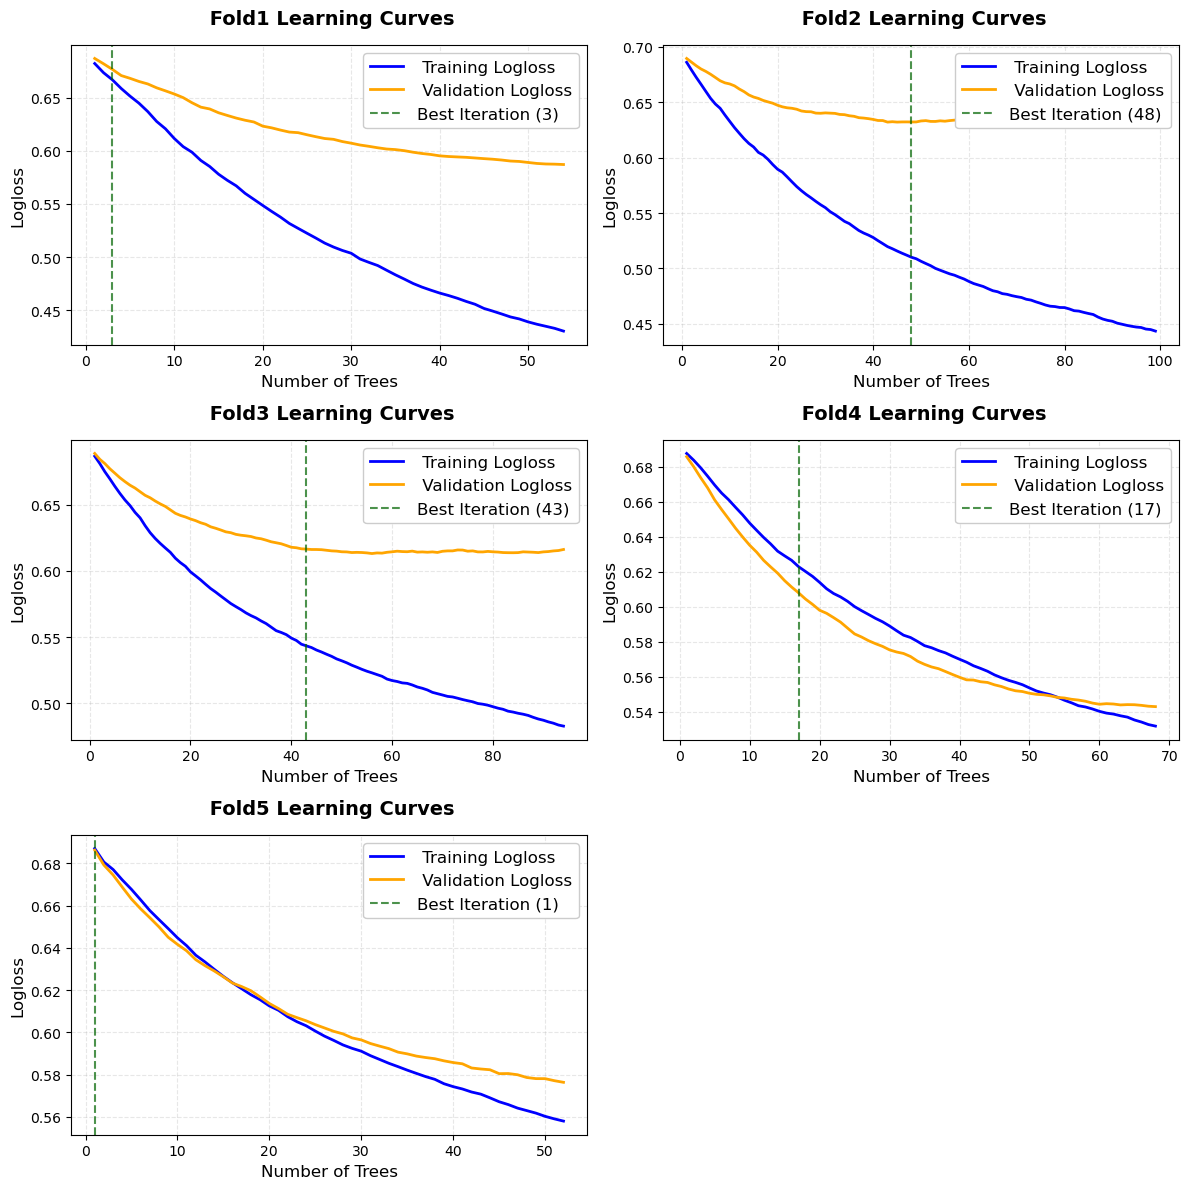

In [229]:
#Generate learning curves
eval_params = best_params.copy()
cv_models_best = []
for i, (train_ind,val_ind) in enumerate(splits):
    train_df = traincat_df.iloc[train_ind]
    val_df = traincat_df.iloc[val_ind]
    X_trcatexp = train_df[feat]
    y_trcatexp = train_df[target]
    X_valcatexp = val_df[feat]
    y_valcatexp = val_df[target]
    #check for folds with only one class in the target column
    if y_trcatexp.nunique()<2:
        if debug:
            print(f"Fold {i} skipped (train fold has only 1 class)")
        skipped_folds +=1
        continue
    if y_valcatexp.nunique()<2:
        if debug:
            print(f"Fold {i} skipped (validation fold has only 1 class)")
        skipped_folds +=1
        continue   
    train_pool = Pool(X_trcatexp, y_trcatexp, cat_features = cat_features)
    val_pool = Pool(X_valcatexp,y_valcatexp,cat_features = cat_features)
    model = CatBoostClassifier(**eval_params)
    model.fit(train_pool, eval_set = val_pool,early_stopping_rounds = 50)
    #Save trained model object for learning curves plotting
    cv_models_best.append(model)
print("Plotting Cross Validation Learning Curves")
plot_learning_curves(cv_models_best, eval_metric = "Logloss")


    

The learning curves show that without early stopping, the CatBoost model overfits and will fail to generalize to unseen data. This behavior is expected for powerful tree‑based models like CatBoost and underscores the importance of early stopping during final training. Accordingly, the average optimal iteration across the 5 folds obtained from the Optuna study was used to control overfitting in the final model.

#### 5.0.2.4 CatBoost Final Model Training and Evaluation

In [232]:
#Train final CatBoost model
#Extract average optimal iterations from the optuna study
optimal_iters = best_trialcat.user_attrs["optimal_iterations"]
print(f"\n Extracted optimal iterations for final model : {optimal_iters}")
print("Training Final model")
#update best params dictionary with the extracted optimal iteration value
best_params["iterations"] = optimal_iters
#Train final CatBoost model using all train dataset
final_model = CatBoostClassifier(**best_params)
train_pool = Pool(X_traincat, y_traincat, cat_features = cat_features)
final_model.fit(train_pool)


 Extracted optimal iterations for final model : 22
Training Final model
0:	total: 2.99ms	remaining: 62.8ms
21:	total: 59.1ms	remaining: 0us


CatBoostClassifier(auto_class_weights='SqrtBalanced', bagging_temperature=2.457315202272584, border_count=92, depth=7, eval_metric='AUC', iterations=22, l2_leaf_reg=17.68872609709418, learning_rate=0.024490983221163463, loss_function='Logloss', random_seed=15, random_strength=0.4597377344211556, verbose=100)

In [233]:
#Determine train auc
preds_train1 = final_model.predict_proba(X_traincat)[:,1]
auc_train1 = roc_auc_score(y_traincat, preds_train1)

print(f"Train AUC: {auc_train1}")

Train AUC: 0.7550798097016584


The difference between the Train AUC of 0.76 and CV AUC of 0.69 is not too high so we can safely conclude that our final trained model does not have a serious overfitting issue. 

**CatBoost Final Model Interpretability and Evaluation**

To support clinical adoption and improve interpretability of the CatBoost model predictions, feature importance and SHapley Additive exPlanations (SHAP) plots were generated. The Feature importance plot was used as a high level diagnostic tool to determine if expected and known drivers of 30-day readmissions are ranked high, while SHAP plots offered detailed insight into how highly ranked features and their values influenced readmission risk for example in what direction does a change in the feature drive 30-day readmission risk. The findings from these analyses are summarized below.

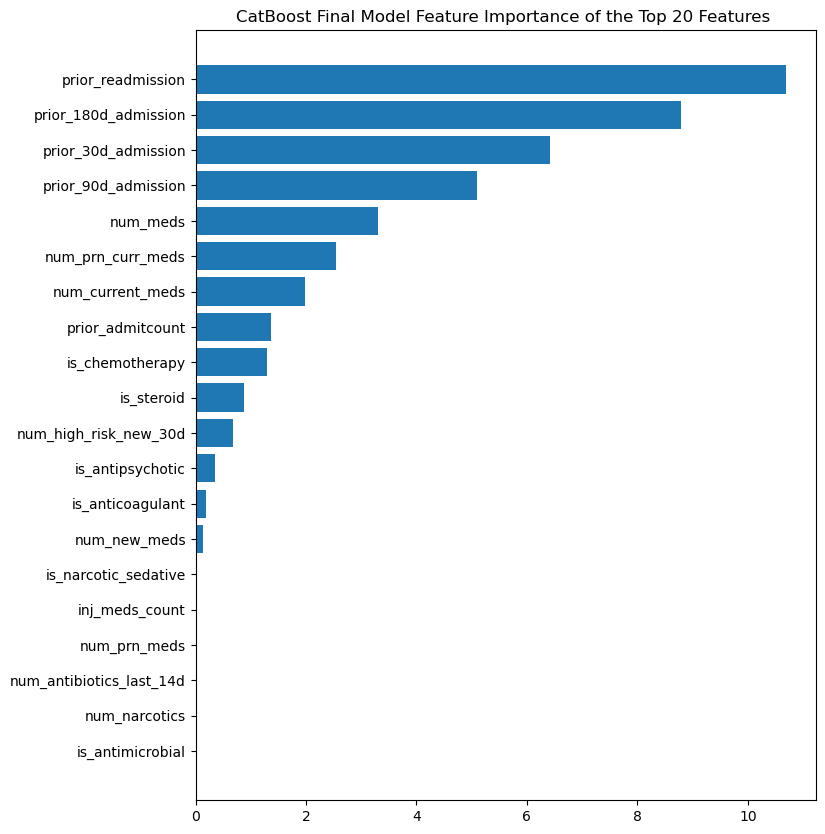

In [236]:
#Generate Feature Importance Plot : Plot only top 20 features
importance = final_model.get_feature_importance(prettified = True)
#print(importance.head(20))
imp = final_model.get_feature_importance()
sorted_idx = np.argsort(imp[:20])
plt.figure(figsize = (8,10))
plt.barh(range(len(sorted_idx)), imp[sorted_idx])
plt.yticks(range(len(sorted_idx)), np.array(feat)[sorted_idx])
plt.title("CatBoost Final Model Feature Importance of the Top 20 Features ")

plt.show()

The feature importance plot highlights the variables that most influenced the CatBoost model’s predictions. A well‑structured readmission model is expected to prioritize utilization, polypharmacy, and comorbidity features, and the plot confirms that this is the case. To further understand how these features influence risk direction and magnitude, SHAP plots were generated and are analyzed below.

In [238]:
train_pool = Pool(X_traincat, y_traincat, cat_features = cat_features)
shap_values = final_model.get_feature_importance(train_pool, type = "ShapValues")
shap_values = shap_values[:,:-1]

In [239]:
shap_df = pd.DataFrame(shap_values, columns = feat)
shap_importance = (shap_df.abs().mean().sort_values(ascending = False))
#print(shap_importance.head(30))

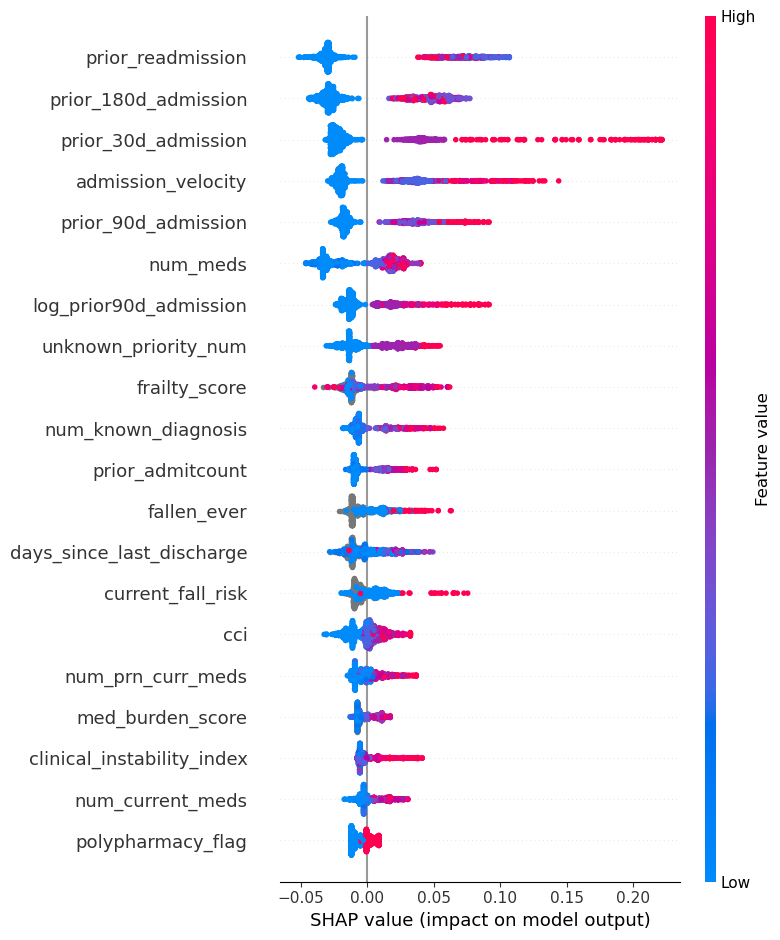

In [240]:
import shap
shap.summary_plot(shap_values, X_traincat, feature_names = feat)
#plt.savefig("shap_sum.png", bbox_inches = "tight", dpi =300)


Analysis of the SHAP plots shows that the top features that the CatBoost model is using to make predictions can be grouped into 4 main categories which are:

1. Utilization features e.g. prior_readmission, prior_180d_admission, admission velocity
2. Medication features e.g. num_meds,med_burden_score,num_prn_curr_meds,polypharmacy_flag
3. Comorbidities features e.g. cci,num_known_diagnosis
4. Frailty features e.g. frailty_score,fallen_ever

Having these four features categories dominating our SHAP plots align with clinical expectations. Past utilization is the single greatest predictor of future utilization and therefore we will expect the features representing past utilization to be at the very top of our SHAP plots which is what we observe. Analyzing the risk direction of some of these features, we observe that as the number of prior_180d_admission or number of  prior_readmission or number of prior_30d_admission increases(represented by red dots), the risk of 30-day readmission increases which is what we expect. Medication and Comorbidities features are related since patients with multiple diagnoses, especially the high risk diagnoses, take a lot of medication which increases the risk of adverse medication interaction.  Both features can be viewed as proxies for disease complexity and polypharmacy risk, known drivers of 30-day readmission, so having them show up as the next set of top predictors after the utilization features is reasonable and matches our observations. Examining the risk direction of these features revealed that as a patient's cci score or medication increases their 30-day readmission risk also increases which is in line with clinical expectation. Clinical evidence links significant frailty and falls history to higher readmission rates, so it is not surprising to see Frailty features show up as part of the 20 top features driving CatBoost prediction. Analysis of frailty features' risk direction shows that as the patient's frailty score or current_fall_risk increases so does their risk of 30-day readmission, this is also in line with our expectation. To further explore these relationships, SHAP dependence plots were analyzed for features within each category. 

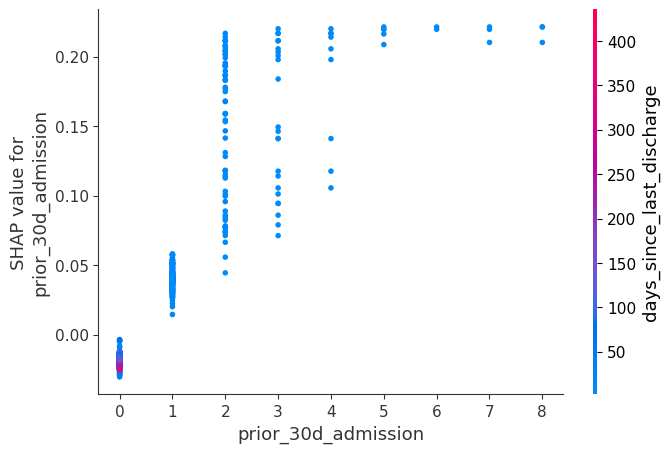

In [242]:
#Utilization features dependence plot example
shap.dependence_plot("prior_30d_admission", shap_values,X_traincat)


The prior_30d_admission dependence plot reveals a close association with the days_since_last_discharge feature. As expected, patients with no prior 30‑day admissions and longer time since last discharge have substantially lower readmission risk than those with one or more prior_30d_admissions and short time since last discharge. Readmission risk also increases with additional prior 30‑day admissions but plateaus after about five events, reflecting a clinical risk ceiling beyond which additional admissions provide limited new information i.e. these patients are already classified into the highest risk category and additional admissions would not change their risk category.

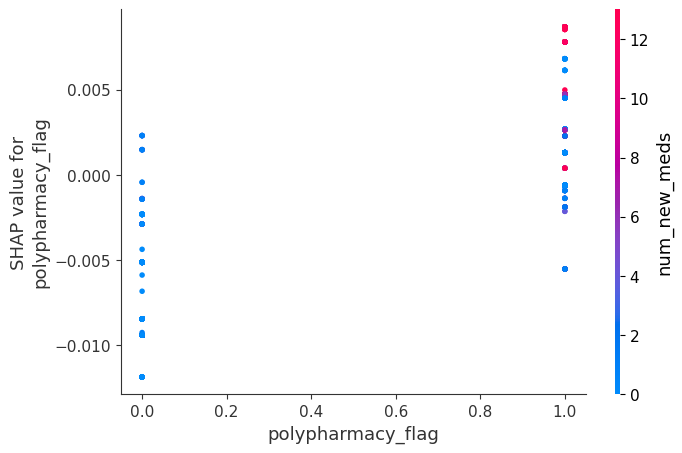

In [244]:
#Medication features dependence plot example
shap.dependence_plot("polypharmacy_flag", shap_values,X_traincat)

The polypharmacy flag plot above shows a close relationship between a patient's polypharmacy status and the number of new medications the patient is taking. From the dependence plot we observe that on average the 30-day readmission risk of patient with a polypharmacy flag value of 1 i.e. taking $\geq$ 5 medication concurrently is higher than those taking less than 5 medications and this risk increases as the number of new medications taken increases. This observation aligns with medical expectations and the SHAP values overlap observed between these two groups of patients is most likely a result of features interactions which will explain why on average patients with polypharmacy flag of 1 and taking low number of new medications have a lower risk of 30-day readmission(lower SHAP value) than those with polypharmacy flag of 1 and taking higher number of new medications.

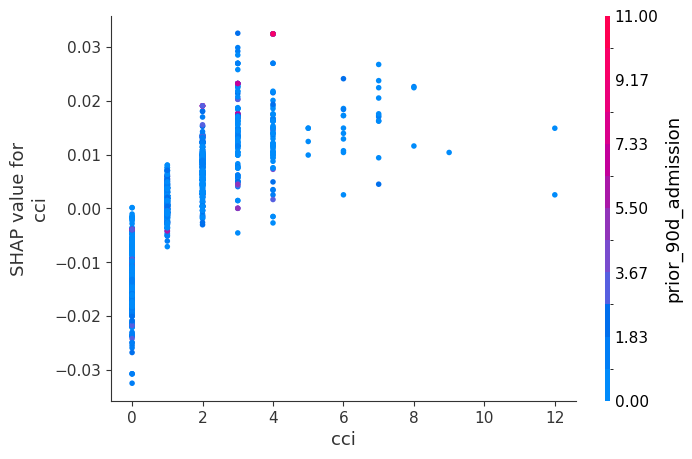

In [246]:
#Comorbidities features dependence plot example
shap.dependence_plot("cci", shap_values,X_traincat)

The CCI plot above shows that a patient's CCI is closely related to their number of prior_90d_admissions. We also observed a trend similar to the utilization feature, prior_30d_admission, where zero cci (healthier patients) corresponds to low readmission risk and increasing cci scores correspond to increasing readmission risk. Mirroring the saturation effect observed with the prior_30d_admission feature, readmission risk plateaus after a cci score of 6. Additionally, for a given CCI level, readmission risk increases as prior 90‑day admissions rise. These patterns are clinically intuitive and align with expectations regarding comorbidities and readmission risk.

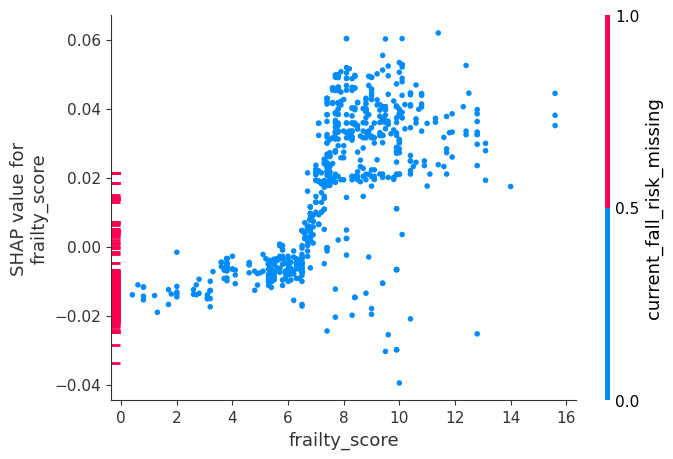

In [248]:
#Frailty features dependence plot example
shap.dependence_plot("frailty_score", shap_values,X_traincat)

Analysis of the frailty score dependence plot shows a close relationship between frailty score and the missingness flag, **current_fall_risk_missing**. Readmission risk remains low for frailty scores below six, suggesting mild frailty and good post‑discharge recovery. Risk rises sharply between scores of six and nine, marking a transition to clinical instability, and then plateaus beyond nine, consistent with advanced frailty. Notably, the model appropriately classifies patients without documented fall risk (current_fall_risk_missing = 1) as low risk, aligning with the expectation that clinicians consistently document fall risk when present.

Taken together, the feature importance rankings, SHAP summary plots, and dependence analyses indicate that the CatBoost model captures clinically meaningful and intuitive patterns, supporting its potential for adoption by medical professionals.

**Feature Selection: Leave-One-Feature-Out**

The CatBoost feature importance plot suggested that some features may have minimal impact on model performance. To identify and remove such features, a leave‑one‑feature‑out (LOFO) study was performed. Similar to an ablation study, LOFO involves removing one feature at a time, retraining the model, and measuring the resulting change in performance. This process was applied to all 72 features used in the CatBoost model. Using a predefined performance threshold and cross‑validation AUC as the evaluation metric, the results were analyzed to determine which features could be excluded from the final model. The results are shown below.

In [251]:
#Function to Test for auc suppressors: LOFO on expanding window
best_auc = best_valuecat
def lofo_imp(df,features,target,splits,params, col_cat):
#col_cat = ["Gender","primary_dx_3dig","primary_dx_3dig_missing"]
    abla_res = []
    for col in features:
        if col in col_cat:
            continue
        feat_remove = col
        #feat_remove
        feat_red = [col for col in features if col not in feat_remove]
        new_auc,_ = run_cv(df ,features = feat_red,target= target, splits = splits, params= params, debug=False)
        abla_res.append({
                "feature" : col,
                "auc_without_feature" : new_auc,
                "delta_auc" : new_auc - best_auc
        
            })

    ablation_df = pd.DataFrame(abla_res).sort_values("delta_auc", ascending = False)
    return ablation_df

In [252]:
#Perform LOFO and display the top 20 features impact AUC
lofo_df = lofo_imp(df= traincat_df,features= feat,target=target,splits=splits,params=best_params, col_cat= ["Gender","primary_dx_3dig","primary_dx_3dig_missing"])
display(lofo_df[:20])

0:	test: 0.6309524	best: 0.6309524 (0)	total: 2.17ms	remaining: 45.7ms
21:	test: 0.6731366	best: 0.6746894 (19)	total: 40.1ms	remaining: 0us

bestTest = 0.674689441
bestIteration = 19

Shrink model to first 20 iterations.
0:	test: 0.6472045	best: 0.6472045 (0)	total: 1.87ms	remaining: 39.3ms
21:	test: 0.6801722	best: 0.7058858 (3)	total: 38.8ms	remaining: 0us

bestTest = 0.7058858221
bestIteration = 3

Shrink model to first 4 iterations.
0:	test: 0.6696691	best: 0.6696691 (0)	total: 1.81ms	remaining: 38ms
21:	test: 0.6750000	best: 0.6837010 (14)	total: 41.1ms	remaining: 0us

bestTest = 0.6837009804
bestIteration = 14

Shrink model to first 15 iterations.
0:	test: 0.6682150	best: 0.6682150 (0)	total: 2.09ms	remaining: 43.8ms
21:	test: 0.6225946	best: 0.6682150 (0)	total: 40.2ms	remaining: 0us

bestTest = 0.6682149967
bestIteration = 0

Shrink model to first 1 iterations.
0:	test: 0.6119814	best: 0.6119814 (0)	total: 3.33ms	remaining: 69.9ms
21:	test: 0.6686177	best: 0.6903081 (2)	total:

,feature,auc_without_feature,delta_auc
7,num_prn_meds,0.696547,0.005949
1,prior_admitcount,0.693955,0.003357
69,is_discharge_weekend,0.692263,0.001665
11,num_high_risk_new_30d,0.689612,-0.000985
54,fall_last_90day,0.687604,-0.002994
22,med_change_ratio,0.687449,-0.003149
10,inj_meds_count,0.687194,-0.003403
57,IsMedicalAllergy,0.686991,-0.003607
55,IsEnvironmentalAllergy,0.686991,-0.003607
13,num_narcotics,0.686920,-0.003677


**LOFO results analysis**

Examination of the delta_auc values showed that removing only three features resulted in slight performance improvements. To avoid overfitting to noise, a predefined threshold of delta_auc > 0.01 was applied for feature removal. Under this criterion, no features qualified for exclusion, and the final model was left unchanged. The next section presents the final model evaluation on the test datasets.

**Final Model Evaluation**

To determine how well out trained CatBoost model generalizes to unseen data, we evaluate our trained model performance on the two test datasets that were used to evaluate our baseline logistic regression model. The results of this evaluation is shown below.

In [255]:
#Determine test auc for new patients
preds_test = final_model.predict_proba(X_testcat)[:,1]
auc_test = roc_auc_score(y_testcat, preds_test)
print(f"Test AUC on new patients: {auc_test}")

Test AUC on new patients: 0.7001779359430605


In [256]:
#Determine test auc for returning and new patients
preds_testall = final_model.predict_proba(X_testcatall)[:,1]
auc_testall = roc_auc_score(y_testcatall, preds_testall)
print(f"Test AUC for both new and returning patients: {auc_testall}")

Test AUC for both new and returning patients: 0.6915537320237058


In [257]:
# Model results comparison
modelres_df = pd.DataFrame({"Train_AUC" : [round(auc_logtrain,2),round(auc_train1,2)],
                        "CV_AUC" : [round(study_lr.best_value,2),round(best_valuecat,2)],
                         "CV_AUC_STD" : [round(best_cvstd,2),round(best_cvstdcat,2)],
                        "Test_AUC(New Clients)" : [round(auc_logtest,2),round(auc_test,2)],
                        "Test_AUC(All Clients)" : [round(auc_logtestall,2),round(auc_testall,2)]
                           }, index = ["Logistic", "CatBoost"])
display(modelres_df)

,Train_AUC,CV_AUC,CV_AUC_STD,Test_AUC(New Clients),Test_AUC(All Clients)
Logistic,0.58,0.53,0.07,0.46,0.48
CatBoost,0.76,0.69,0.03,0.70,0.69


**Evaluation Results Analysis**

The performance comparison table revealed that our baseline logistic regression model didn't generalize well and performed worse than random guessing on the test datasets. This outcome is unsurprising, as the model relied primarily on weak predictors (age, gender, and number of diagnoses), which were identified through EDA and SHAP analyses as having limited predictive power. In contrast, the CatBoost model, trained on 72 raw and engineered features, achieved a substantial 21–24% improvement in test AUC over the logistic regression model. This 44%-52% improvement in the CatBoost model performance indicates that the engineered features successfully captured relevant clinical signals much more effectively than age + gender + number of diagnoses alone. Moreover, the small gap between train and cross‑validation AUCs, the minimal difference between CV and test AUCs, and the low CV AUC variance suggest strong generalization potential in production. Notably, a slight drop in test AUC was observed when evaluating the model on a dataset containing both new and returning patients, which may indicate greater difficulty in classifying returning patients, a plausible outcome given the higher noise and complexity typically associated with this group of patients' data. 


## 6.0 CatBoost Model Performance Metrics and Operational Threshold Determination

Due to the class imbalance in our dataset, a model that predicts no readmission for all patients can still achieve high accuracy, making accuracy an unreliable metric. As a result, we focus on more informative performance measures such as ROC‑AUC, PR‑AUC, recall, and precision. In practice, users of 30‑day readmission models care most about three outcomes:

1. How well the model ranks high risk patients (ROC-AUC, PR-AUC, Brier Score)
2. How well does the model correctly classify readmitted patients as positives (Sensitivity/Recall)
3. How well does the model avoid inundating clinicians with false alarms (Precision)
   
Accordingly, we can group the aforementioned performance metrics into **Ranking Metrics(Probability Threshold Independent)** and **Operational Metrics(Probability Threshold Dependent)**. To finalize the evaluation of our CatBoost model, we computed additional ranking metrics and selected an operational probability threshold by maximizing recall under a precision constraint. For this analysis, we used a precision constraint of 0.20, a value that can be adjusted to align with specific clinical or caregiver agency goals. The results are presented below.

In [260]:
#function to evaluate final model
from sklearn.metrics import(precision_recall_curve,auc,brier_score_loss,RocCurveDisplay,
                            classification_report,confusion_matrix,precision_score,recall_score)
def model_evaluation(y_true, y_probs, min_precision = 0.2, dataset= "Test"):
    #Calculate threshold independent metrics
    precision,recall,thresholds = precision_recall_curve(y_true,y_probs)
    pr_auc = auc(recall,precision)
    roc_auc = roc_auc_score(y_true,y_probs)
    brier_score = brier_score_loss(y_true,y_probs)

    #Find operational threhold (Maximize recall under precision constraint)
    best_thresh, best_recall = 0,0
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        precision = precision_score(y_true,preds,zero_division=0)
        recall = recall_score(y_true,preds)
        if precision >= min_precision and recall > best_recall:
            best_recall = recall
            best_thresh = t
    y_pred_opt = (y_probs >= best_thresh).astype(int)
    #Print evaluation results
    print(f"30-Day Catboost Readmission Model Evaluation on {dataset} Dataset")
    print("="*60)
    print(f"ROC_AUC : {roc_auc:.4f}")
    print(f"PR_AUC : {pr_auc:.4f}")
    print(f"Brier Score : {brier_score:.4f}")
    print("-"*60)
    print(f"Optimal Threshold Probability: {best_thresh}")
    print(f"Best Recall when Precision is >= {min_precision} : {best_recall:.4f}")
    print("-"*60)
    print("Classification Report at Optimal Threshold:")
    print(classification_report(y_true,y_pred_opt, target_names=["No Readmit","Readmit"]))
    cm = confusion_matrix(y_true,y_pred_opt)
    print("Confusion Matrix to highlight Operational Impact")
    print(cm)
    print(f"True Negatives(Correctly classified as safe from readmission) : {cm[0][0]}")
    print(f"False Positives(Incorrect alerts) : {cm[0][1]}")
    print(f"False Negatives( Missed readmissions) : {cm[1][0]}")
    print(f"True Positives( Successfully flagged readmissions) : {cm[1][1]}")
    print("="*60)

    #Plot ROC Curve
    plt.figure(figsize = (10,8))
    RocCurveDisplay.from_predictions(y_true,y_probs)
    #plt.plot(recall,precision, label = f" CatBoost PR Curve (AUC = {pr_auc:.3f})", color = "purple", lw=2)
    # Plot the optimal recall
    #plt.axvline(x= best_recall, color = "darkgreen", linestyle = "--", label = f"Best recall({best_recall})")
    #baseline_rate = np.mean(y_true)
    #plt.axhline(y = baseline_rate, color = "brown", linestyle="--", label = f"Random Guess Baseline ({baseline_rate*100:.0f}%)")
    plt.title("30-Day Hospital Readmission CatBoost Model ROC_AUC Curve",fontsize = 12)
    plt.xlabel("False Positive Rate", fontsize = 12)
    plt.ylabel("True Positive Rate", fontsize = 12)
    plt.legend(loc="upper right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    
    
        


    


30-Day Catboost Readmission Model Evaluation on Test Dataset
ROC_AUC : 0.7002
PR_AUC : 0.3164
Brier Score : 0.1697
------------------------------------------------------------
Optimal Threshold Probability: 0.3721792878034064
Best Recall when Precision is >= 0.2 : 0.7368
------------------------------------------------------------
Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

  No Readmit       0.94      0.60      0.73       281
     Readmit       0.20      0.74      0.31        38

    accuracy                           0.62       319
   macro avg       0.57      0.67      0.52       319
weighted avg       0.86      0.62      0.68       319

Confusion Matrix to highlight Operational Impact
[[169 112]
 [ 10  28]]
True Negatives(Correctly classified as safe from readmission) : 169
False Positives(Incorrect alerts) : 112
False Negatives( Missed readmissions) : 10
True Positives( Successfully flagged readmissions) : 28


<Figure size 1000x800 with 0 Axes>

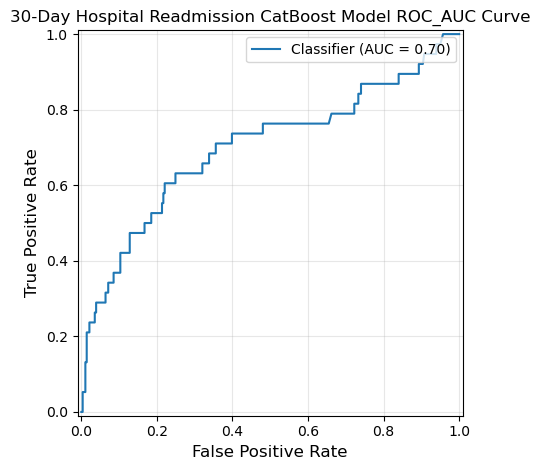

In [261]:
model_evaluation(y_testcat, preds_test, min_precision = 0.2, dataset= "Test")

**Results Analysis and Conclusion**

PR_AUC (Precision-Recall AUC) measures the area under the curve plotting precision against recall at different thresholds and is particularly well suited for highly imbalanced datasets because it focuses on the minority class. A good model should have a PR_AUC value above its dataset prevalence which will be 0.12 for our test dataset. Our CatBoost model achieved a PR‑AUC of 0.32, substantially above this baseline. The Brier score measures the accuracy of probabilistic forecast for binary outcomes with lower scores indicating better calibration and accuracy. It ranges from 0 (perfect prediction) to 1 (worst prediction). A score of 0.25 corresponds to predicting a constant probability of 0.5 for all cases. Our CatBoost model achieved a Brier score of 0.169, which is below the 0.25 threshold but is slightly higher than our test dataset baseline of 0.11 (0.12*(1-0.12)). This slightly high score is likely driven by our train-to-test dataset class imbalance shift of 22% to 12%, and indicates that our model probabilities may not be well calibrated. 

The recommended operational probability threshold for deployment is 0.372. At this threshold, the model achieves a sensitivity of 0.74 and a precision of 0.20, meaning it correctly identifies 74% of true 30‑day readmissions while 20% of patients flagged as high risk are actually readmitted. Although this precision may appear low, it reflects an appropriate trade‑off in a clinical context, where the cost of missing a readmission typically outweighs the cost of preventative interventions such as outreach or follow‑up calls. Based on these additional performance metrics, we expect our CatBoost model after probability calibration to generalize and perform reasonably in production. 

Our model’s inability to reach the target test AUC of 0.75 is likely due to our small dataset size, data quality issues and missing clinical features not provided and subsequently not captured in our dataset, variables such as social determinants of health, discharge planning details, actual discharge dates, reason for hospitalization and follow‑up appointment information. Recommendations on steps that could be taken to further improve on the predictive power of our CatBoost model are provided in the Recommendation section of our Final Report.   

**Risk Stratification**

In this section, we describe our risk stratification logic. Given the slightly elevated Brier score observed on the test dataset, and to mitigate the risk of excessive false alerts, we recommend applying post-hoc probability calibration prior to using model outputs for clinical risk stratification. This step helps correct for potential probability drift and improves the reliability of predicted risk estimates. Alternatively, predicted probabilities may be adjusted using a Bayesian prior correction to account for shifts in class prevalence between training and deployment settings. Platt scaling or isotonic regression are appropriate calibration methods to consider.

For risk stratification, we recommend using our operational probability threshold as the boundary seperating low risk from medium risk patients, and a threshold of 0.5 as the boundary separating medium risk patients from high risk patients. This upper boundary may be adjusted based on clinical priorities, resource constraints, or accceptable sensitivity-specificity trade-offs . Option to make this adjustment can be found in the Import Model Artifact code block below.

**Deployment Notes**

Caryfy's team has the option to set predicted model probabilities to NaNs if there is a bad data quality flag for that observation by uncommenting the code under the **Optional** comment line in the Import Model Artifact code block below. 

Default output setting: Predicted model probabilities are returned without adjustment, allowing users to leverage the data quality flag when determining how much to trust the model's predictions. Since CatBoost handles missing data natively, we expect data missingness to have a relatively limited impact on prediction performance.

# Save Model Artifacts

In [266]:
# ============================================================
# Save All Important Model Artifacts
# ============================================================
import pickle
import json
import os

ARTIFACT_DIR = "model_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# ----------------------------------------------------------
# 1. CatBoost final model (native format — most reliable)
# ----------------------------------------------------------
final_model.save_model(os.path.join(ARTIFACT_DIR, "catboost_final_model.cbm"))
print("✓ CatBoost model saved (native .cbm)")

# Also save as pickle for convenience
with open(os.path.join(ARTIFACT_DIR, "catboost_final_model.pkl"), "wb") as f:
    pickle.dump(final_model, f)
print("✓ CatBoost model saved (.pkl)")

# ----------------------------------------------------------
# 2. Risk component scaler (fitted in Cell 124)
# ----------------------------------------------------------
with open(os.path.join(ARTIFACT_DIR, "risk_scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
print("✓ Risk component scaler saved (.pkl)")

# ----------------------------------------------------------
# 
# ----------------------------------------------------------
# 4. Best hyperparameters as JSON (human-readable backup)
# ----------------------------------------------------------
best_params_cb = best_params.copy()

with open(os.path.join(ARTIFACT_DIR, "best_params_catboost.json"), "w") as f:
    json.dump(best_params_cb, f, indent=2)
print("✓ Best hyperparameters saved (.json)")

# ----------------------------------------------------------
# 5. Feature lists
# ----------------------------------------------------------
feature_config = {
    "features_numeric": features_numeric,
    "features_binary": features_binary,
    "features_cat": features_cat,
    "feat_catboost": feat,                  # full CatBoost feature list
    "cat_features": cat_features,           # categorical feature names for CatBoost Pool
    "risk_scaler_columns": components_risk, # columns the risk scaler was fitted on
    "target": target,
}
with open(os.path.join(ARTIFACT_DIR, "feature_config.json"), "w") as f:
    json.dump(feature_config, f, indent=2)
print("✓ Feature configuration saved (.json)")

# ----------------------------------------------------------
# 6. SHAP values (optional — can be large)
# ----------------------------------------------------------
with open(os.path.join(ARTIFACT_DIR, "shap_values.pkl"), "wb") as f:
    pickle.dump(shap_values, f)

shap_df.to_parquet(os.path.join(ARTIFACT_DIR, "shap_importance.parquet"), index=False)
print("✓ SHAP values and importance saved")

# ----------------------------------------------------------
# 7. Model performance summary
# ----------------------------------------------------------
performance = {
    "catboost": {
        "train_auc": round(auc_train1, 4),
        "cv_auc": round(best_valuecat, 4),
        "cv_auc_std": round(best_cvstdcat, 4),
        "test_auc_new_clients": round(auc_test, 4),
        "test_auc_all_clients": round(auc_testall, 4),
    }
}
with open(os.path.join(ARTIFACT_DIR, "model_performance.json"), "w") as f:
    json.dump(performance, f, indent=2)
print("✓ Model performance summary saved (.json)")

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print(f"\nAll artifacts saved to: ./{ARTIFACT_DIR}/")
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    size_kb = os.path.getsize(os.path.join(ARTIFACT_DIR, fname)) / 1024
    print(f"  {fname:<45} {size_kb:>8.1f} KB")

✓ CatBoost model saved (native .cbm)
✓ CatBoost model saved (.pkl)
✓ Risk component scaler saved (.pkl)
✓ Best hyperparameters saved (.json)
✓ Feature configuration saved (.json)
✓ SHAP values and importance saved
✓ Model performance summary saved (.json)

All artifacts saved to: ./model_artifacts/
  best_params_catboost.json                          0.3 KB
  catboost_final_model.cbm                          56.7 KB
  catboost_final_model.pkl                          58.5 KB
  feature_config.json                                3.7 KB
  model_performance.json                             0.2 KB
  optuna_study_catboost.pkl                          0.0 KB
  risk_scaler.pkl                                    0.7 KB
  shap_importance.parquet                          308.4 KB
  shap_values.pkl                                  995.2 KB


# Import Model Artifacts and Run (must have all necessary files)

In [269]:
# ============================================================
# Load Artifacts and Run Inference
# ============================================================
import pickle
import json
import os
import numpy as np
import pandas as pd
import logging
from catboost import CatBoostClassifier, Pool
from datetime import datetime

logging.basicConfig(level=logging.INFO)

ARTIFACT_DIR = "model_artifacts"

# ----------------------------------------------------------
# 1. Load feature configuration
# ----------------------------------------------------------
with open(os.path.join(ARTIFACT_DIR, "feature_config.json"), "r") as f:
    feature_config = json.load(f)

features_numeric   = feature_config["features_numeric"]
features_binary    = feature_config["features_binary"]
features_cat       = feature_config["features_cat"]
feat               = feature_config["feat_catboost"]
cat_features       = feature_config["cat_features"]
components_risk    = feature_config["risk_scaler_columns"]
target             = feature_config["target"]

logging.info(f"Feature config loaded | CatBoost features: {len(feat)}")

# ----------------------------------------------------------
# 2. Load scaler
# ----------------------------------------------------------
with open(os.path.join(ARTIFACT_DIR, "risk_scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)

logging.info("Risk component scaler loaded")

# ----------------------------------------------------------
# 3. Load model
# ----------------------------------------------------------
catboost_model = CatBoostClassifier()
catboost_model.load_model(os.path.join(ARTIFACT_DIR, "catboost_final_model.cbm"))

logging.info("CatBoost model loaded")

# ----------------------------------------------------------
# 4. Load performance summary
# ----------------------------------------------------------
with open(os.path.join(ARTIFACT_DIR, "model_performance.json"), "r") as f:
    performance = json.load(f)

for model_name, metrics in performance.items():
    logging.info(f"{model_name}: Test AUC (new clients) = {metrics['test_auc_new_clients']}")

# ============================================================
# Preprocessing
# ============================================================

def preprocess_new_data(df: pd.DataFrame):
    df = df.copy()

    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")

    quality_flags = pd.DataFrame(index=df.index)

    # ---------------------------
    # Missing critical features
    # ---------------------------
    missing_feat = [c for c in feat if c not in df.columns]
    quality_flags["missing_critical_features"] = int(len(missing_feat) > 0)

    if missing_feat:
        logging.warning(f"Missing critical features: {missing_feat}")

    available_feat = [c for c in feat if c in df.columns]

    # ---------------------------
    # Risk scaler
    # ---------------------------
    cols_present = [c for c in components_risk if c in df.columns]
    cols_missing = [c for c in components_risk if c not in df.columns]

    quality_flags["missing_risk_columns"] = int(len(cols_missing) > 0)

    if cols_missing:
        logging.warning(f"Missing risk scaler columns: {cols_missing}")

    if cols_present:
        df[cols_present] = scaler.transform(df[cols_present])

    # ---------------------------
    # Missing feature ratio
    # ---------------------------
    if available_feat:
        missing_counts = df[available_feat].isna().sum(axis=1)
        quality_flags["high_missing_rate"] = (missing_counts / len(available_feat) > 0.2).astype(int)
    else:
        quality_flags["high_missing_rate"] = 1

    # ---------------------------
    # Categorical fill
    # ---------------------------
    for col in features_cat:
        if col in df.columns:
            df[col] = df[col].fillna("UNKNOWN").astype(str).str.strip()

    # ---------------------------
    # Indicator fills
    # ---------------------------
    for col in ["primary_dx_3dig_missing", "current_fall_risk_missing", "days_since_last_fall_missing"]:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    if "num_known_diagnosis" in df.columns:
        df["num_known_diagnosis"] = df["num_known_diagnosis"].fillna(0)

    if "Gender" in df.columns:
        df["Gender"] = df["Gender"].fillna("UNKNOWN")

    return df, quality_flags


# ============================================================
# Prediction
# ============================================================

def predict_catboost(df: pd.DataFrame) -> pd.Series:
    available_feat = [c for c in feat if c in df.columns]

    if len(available_feat) == 0:
        raise ValueError("No valid features available for prediction")

    X = df.reindex(columns=feat)  # ensures correct order + missing columns handled
    pool = Pool(X, cat_features=cat_features)

    probs = catboost_model.predict_proba(pool)[:, 1]
    return pd.Series(probs, index=df.index, name="catboost_readmission_prob")


# ============================================================
# Full Pipeline
# ============================================================

def predict_all(df: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:

    df_proc, quality_flags = preprocess_new_data(df)

    results = pd.DataFrame(index=df.index)

    # ---------------------------
    # IDs
    # ---------------------------
    for id_col in ["UUID", "DischargeDate", "HospitalizationDate"]:
        if id_col in df.columns:
            results[id_col] = df[id_col]

    # ---------------------------
    # Predictions
    # ---------------------------
    results["catboost_readmission_prob"] = predict_catboost(df_proc)

    p = results["catboost_readmission_prob"]

    # ---------------------------
    # Risk segmentation
    # ---------------------------
    results["catboost_high_risk_flag"]   = (p > threshold).astype(int)
    results["catboost_medium_risk_flag"] = ((p >= 0.372) & (p <= threshold)).astype(int)
    results["catboost_low_risk_flag"]    = (p < 0.372).astype(int)

    # ---------------------------
    # Data Quality Flag
    # ---------------------------
    results["data_quality_flag"] = (
        (quality_flags["missing_critical_features"] == 1) |
        (quality_flags["missing_risk_columns"] == 1) |
        (quality_flags["high_missing_rate"] == 1)
    ).astype(int)

    # ---------------------------
    # Data Quality Issues (clean)
    # ---------------------------
    issues_list = []

    for idx in results.index:
        issues = []
        if quality_flags.loc[idx, "missing_critical_features"]:
            issues.append("missing_critical_features")
        if quality_flags.loc[idx, "missing_risk_columns"]:
            issues.append("missing_risk_columns")
        if quality_flags.loc[idx, "high_missing_rate"]:
            issues.append("high_missing_rate")

        issues_list.append(",".join(issues))

    results["data_quality_issues"] = issues_list

    # ---------------------------
    # Prediction validity
    # ---------------------------
    results["prediction_valid"] = (results["data_quality_flag"] == 0).astype(int)

    # Optional: null out bad predictions (uncomment the line below to activate)
    #results.loc[results["prediction_valid"] == 0, "catboost_readmission_prob"] = np.nan

    # ---------------------------
    # Metadata
    # ---------------------------
    now = datetime.now()

    results["scoring_timestamp"] = now
    results["as_of_date"] = now
    results["reference_date"] = results["DischargeDate"] if "DischargeDate" in results.columns else None
    results["model_version"] = "1.0.0"
    results["feature_version"] = "1.0"

    return results


# ============================================================
# Example Usage
# ============================================================

# results = predict_all(new_patients_df, threshold=0.5)
# print(results.head())

INFO:root:Feature config loaded | CatBoost features: 72
INFO:root:Risk component scaler loaded
INFO:root:CatBoost model loaded
INFO:root:catboost: Test AUC (new clients) = 0.7002


In [270]:
#Example Usage : Uncomment to run
#results = predict_all(testcat_dfblind, threshold = 0.5)
#display(results.tail(10))